# Olist Brazilian E-Commerce — Analytical EDA Project

## Project Overview
This notebook presents an exploratory data analysis of the **Olist Brazilian E-Commerce Dataset** — a real multi-table dataset from an actual Brazilian marketplace covering ~100,000 orders placed between 2016 and 2018.

The analysis is structured across 6 phases: data loading, cleaning, master table construction, descriptive EDA, hypothesis testing, and predictive modeling.

---

## Research Questions

### Question 1 — Pricing Perception vs Operational Performance
> *"Does freight cost as a percentage of product price systematically predict customer review scores independent of delivery speed — and what is the relative contribution of pricing perception versus operational performance in determining customer satisfaction?"*

### Question 2 — Seller Lifecycle Trust Erosion
> *"Do Olist sellers follow a predictable lifecycle of trust erosion — where early operational decisions create compounding effects that determine their long-term review trajectory — and can we identify a leading behavioral signal that a seller is deteriorating before customers begin punishing them in reviews?"*

---

## Dataset
- **Source:** Olist Brazilian E-Commerce Public Dataset (Kaggle)
- **Tables:** 9 CSV files covering orders, items, payments, reviews, customers, sellers, products, geolocation
- **Time period:** September 2016 – October 2018
- **Scale:** ~100,000 real anonymized orders

---

## Tech Stack
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scipy` · `Scikit-learn`


---
## Phase 1 — Data Loading

Load all 9 raw Olist CSV tables into memory. Each table represents a distinct entity in the marketplace data model and will be cleaned independently before being joined into a master analytical table.


In [1]:
# Import pandas for data manipulation and suppress non-critical warnings for clean output
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
# Load all 9 raw Olist CSV files into separate DataFrames for independent profiling and cleaning
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

print("All tables loaded successfully")

All tables loaded successfully


In [3]:
# Display shape, column names, and first 2 rows of every table to understand raw data structure
from IPython.display import display

for name, df in [('orders', orders),
                 ('order_items', order_items),
                 ('order_payments', order_payments),
                 ('order_reviews', order_reviews),
                 ('customers', customers),
                 ('sellers', sellers),
                 ('products', products),
                 ('category_translation', category_translation),
                 ('geolocation', geolocation)]:
    print(f"{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head(2))
    print('\n')

ORDERS
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00




ORDER_ITEMS
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93




ORDER_PAYMENTS
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0




CATEGORY_TRANSLATION
Shape: (71, 2)
Columns: ['product_category_name', 'product_category_name_english']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories




GEOLOCATION
Shape: (1000163, 5)
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP


In [4]:
# Check null counts and percentages across all 9 tables to identify which columns need cleaning
datasets = {
    'orders': orders,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'category_translation': category_translation,
    'geolocation': geolocation
}

for name, df in datasets.items():
    print(f"{name.upper()}")
    null_counts = df.isnull().sum()
    null_pct = round((null_counts / len(df) * 100),2)

    null_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null %': null_pct
    })

    result = null_df[null_df['Null Count'] > 0]

    if not result.empty:
        display(result.sort_values('Null Count', ascending=False))
    else:
        print("No null values found")
    print("\n")

ORDERS


,Null Count,Null %
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16




ORDER_ITEMS
No null values found


ORDER_PAYMENTS
No null values found


ORDER_REVIEWS


,Null Count,Null %
review_comment_title,87656,88.34
review_comment_message,58247,58.70




CUSTOMERS
No null values found


SELLERS
No null values found


PRODUCTS


,Null Count,Null %
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01




CATEGORY_TRANSLATION
No null values found


GEOLOCATION
No null values found




---
## Phase 2 — Data Profiling and Cleaning

Before any cleaning decisions, we profile every table to understand:
- Shape and column structure
- Data types (object vs numeric vs datetime)
- Null counts and percentages
- Duplicate rows
- Suspicious or impossible values

Cleaning decisions are made **after** seeing the data, not before.


### 2.1 Orders Table

The orders table is the **spine of the entire analysis**. Every other table joins to it via `order_id`. It contains delivery timestamps that are the foundation of both research questions.


In [5]:
# Profile the orders table in detail — dtypes, null breakdown, status distribution, and timestamp range
print("ORDERS — BEFORE CLEANING")
print('\n')

print(f"Shape: {orders.shape}")
print('\n')

print("Columns and Data Types:")
print(orders.dtypes)
print('\n')

print("Null Counts:")
null_counts = orders.isnull().sum()
null_pct = (orders.isnull().sum() / len(orders) * 100).round(2)
null_df = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_pct
})
display(null_df[null_df['Null Count'] > 0])
print('\n')

print("Order Status Distribution:")
print(orders['order_status'].value_counts())
print('\n')

print(f"Duplicate order_ids: {orders['order_id'].duplicated().sum()}")
print(f"Unique order_ids:    {orders['order_id'].nunique()}")
print('\n')

print("Timestamp Range:")
for col in ['order_purchase_timestamp', 'order_estimated_delivery_date']:
    print(f"  {col}:")
    print(f"    Min: {orders[col].min()}")
    print(f"    Max: {orders[col].max()}")

ORDERS — BEFORE CLEANING


Shape: (99441, 8)


Columns and Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


Null Counts:


,Null Count,Null %
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98




Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Duplicate order_ids: 0
Unique order_ids:    99441


Timestamp Range:
  order_purchase_timestamp:
    Min: 2016-09-04 21:15:19
    Max: 2018-10-17 17:30:18
  order_estimated_delivery_date:
    Min: 2016-09-30 00:00:00
    Max: 2018-11-12 00:00:00


In [6]:
# Keep only delivered orders with complete timestamps — cancelled or undelivered orders have no delivery metrics
# 97% of orders survive this filter (96,455 of 99,441)
import numpy as np

orders_clean = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notnull()) &
    (orders['order_delivered_carrier_date'].notnull()) &
    (orders['order_approved_at'].notnull())
].copy()

print(f"Original orders:  {len(orders)}")
print(f"Cleaned orders:   {len(orders_clean)}")
print(f"Rows removed:     {len(orders) - len(orders_clean)}")
print(f"Rows kept:        {round(len(orders_clean) / len(orders) * 100, 2)}%")

Original orders:  99441
Cleaned orders:   96455
Rows removed:     2986
Rows kept:        97.0%


In [7]:
# Convert all 5 timestamp columns from string (object) to datetime64 to enable date arithmetic
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

print("Timestamp conversion complete")
print(orders_clean.dtypes)

Timestamp conversion complete
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [8]:
# Calculate 4 derived delivery metrics: promise gap, total delivery days, carrier pickup days, transit days
# promise_gap_days is our primary Q1 variable — negative means early delivery, positive means late
orders_clean['promise_gap_days'] = (
    orders_clean['order_delivered_customer_date'] - 
    orders_clean['order_estimated_delivery_date']
).dt.days

orders_clean['actual_delivery_days'] = (
    orders_clean['order_delivered_customer_date'] - 
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['carrier_pickup_days'] = (
    orders_clean['order_delivered_carrier_date'] - 
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['delivery_to_customer_days'] = (
    orders_clean['order_delivered_customer_date'] - 
    orders_clean['order_delivered_carrier_date']
).dt.days

print("Delivery metrics calculated")
print("New columns added:")
display(orders_clean[['promise_gap_days', 
                     'actual_delivery_days',
                     'carrier_pickup_days',
                     'delivery_to_customer_days']].describe())

Delivery metrics calculated
New columns added:


,promise_gap_days,actual_delivery_days,carrier_pickup_days,delivery_to_customer_days
count,96455.000000,96455.000000,96455.000000,96455.000000
mean,-11.874584,12.093100,2.736198,8.878140
std,10.181726,9.551209,3.611623,8.746466
min,-147.000000,0.000000,-172.000000,-17.000000
25%,-17.000000,6.000000,1.000000,4.000000
50%,-12.000000,10.000000,2.000000,7.000000
75%,-7.000000,15.000000,4.000000,12.000000
max,188.000000,209.000000,125.000000,205.000000


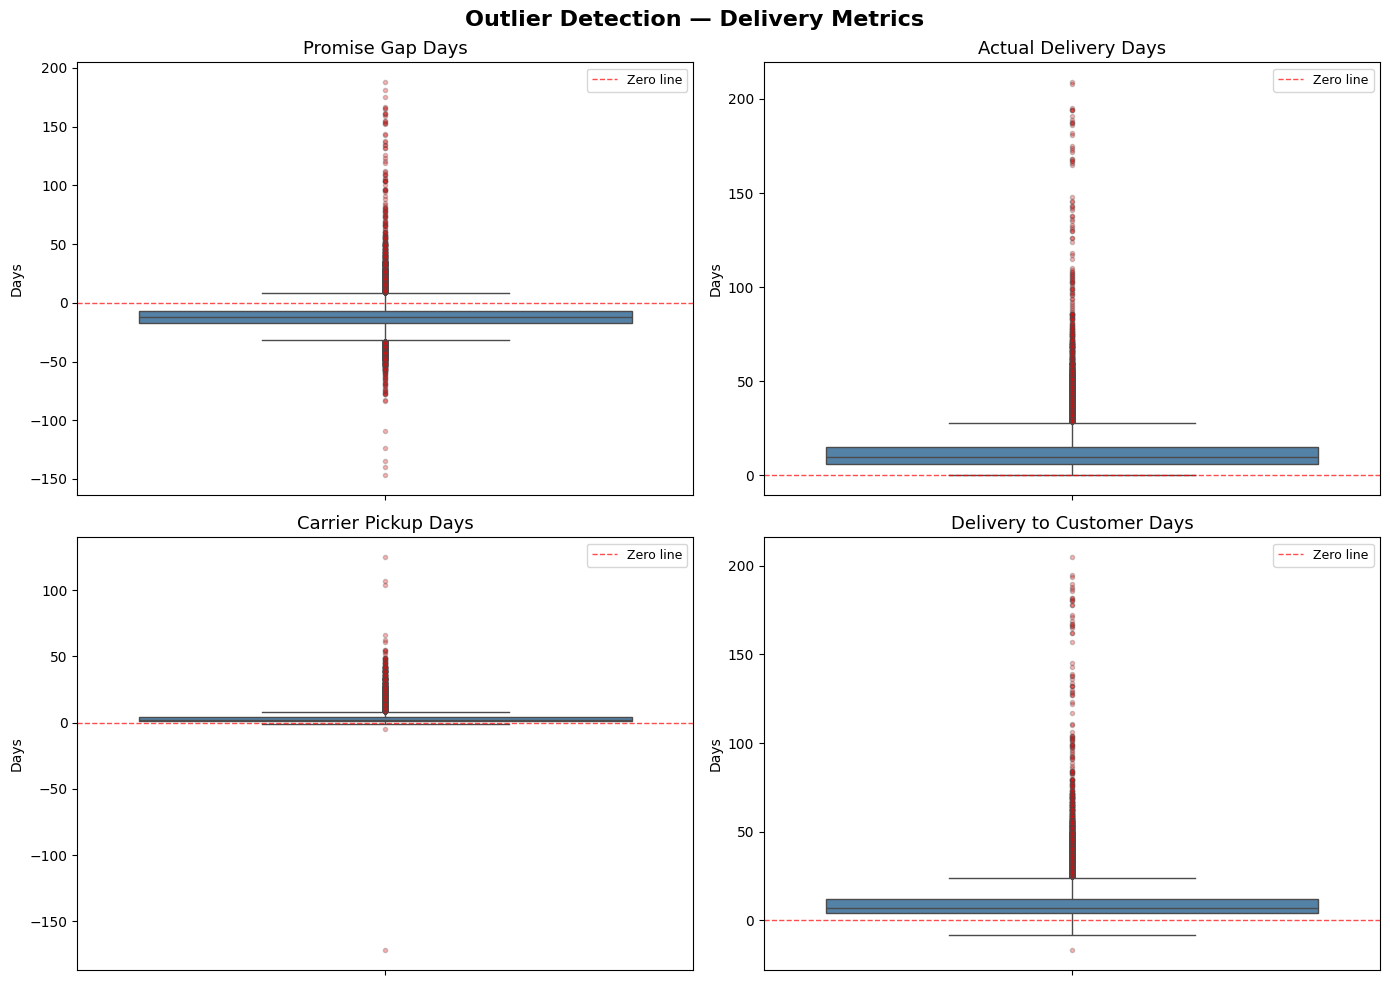

In [9]:
# Visualize outlier distribution across 4 delivery metrics using box plots before setting removal thresholds
# Red dots above and below whiskers are outliers — zero line confirms which values are physically impossible
import matplotlib.pyplot as plt 
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outlier Detection — Delivery Metrics', 
             fontsize=16, fontweight='bold')

cols = [
    ('promise_gap_days',          'Promise Gap Days',          axes[0, 0]),
    ('actual_delivery_days',      'Actual Delivery Days',      axes[0, 1]),
    ('carrier_pickup_days',       'Carrier Pickup Days',       axes[1, 0]),
    ('delivery_to_customer_days', 'Delivery to Customer Days', axes[1, 1])
]

for col, title, ax in cols:
    sns.boxplot(
        y=orders_clean[col],
        ax=ax,
        color='steelblue',
        flierprops=dict(marker='o', markerfacecolor='red',
                        markersize=3, alpha=0.3)
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Days')
    ax.axhline(y=0, color='red', linestyle='--',
               alpha=0.7, linewidth=1, label='Zero line')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# Calculate IQR-based bounds (factor=3.0) for each delivery metric to set statistically principled outlier thresholds
def get_iqr_bounds(series, factor=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return round(lower, 2), round(upper, 2)

for col in ['promise_gap_days', 'actual_delivery_days',
            'carrier_pickup_days', 'delivery_to_customer_days']:
    lower, upper = get_iqr_bounds(orders_clean[col])
    print(f"{col}: lower={lower}, upper={upper}")

promise_gap_days: lower=-47.0, upper=23.0
actual_delivery_days: lower=-21.0, upper=42.0
carrier_pickup_days: lower=-8.0, upper=13.0
delivery_to_customer_days: lower=-20.0, upper=36.0


In [11]:
# Remove outliers using IQR-informed bounds — eliminates impossible values while preserving ~95.7% of the data
before_count = len(orders_clean)
print(f"BEFORE OUTLIER REMOVAL")
print(f"Total orders: {before_count}")

orders_clean = orders_clean[
    (orders_clean['promise_gap_days'] >= -47) &
    (orders_clean['promise_gap_days'] <= 30) &
    (orders_clean['actual_delivery_days'] >= 0) &
    (orders_clean['actual_delivery_days'] <= 42) &
    (orders_clean['carrier_pickup_days'] >= 0) &
    (orders_clean['carrier_pickup_days'] <= 13) &
    (orders_clean['delivery_to_customer_days'] >= 0) &
    (orders_clean['delivery_to_customer_days'] <= 32)
].copy()

after_count = len(orders_clean)
print('\n')
print(f"AFTER OUTLIER REMOVAL")
print(f"Total orders:  {after_count}")
print(f"Rows removed:  {before_count - after_count}")
print(f"Rows kept:     {round(after_count / before_count * 100, 2)}%")

BEFORE OUTLIER REMOVAL
Total orders: 96455


AFTER OUTLIER REMOVAL
Total orders:  92315
Rows removed:  4140
Rows kept:     95.71%


In [12]:
# Create delivery_status column: 'early' if promise_gap < 0, 'on_time' if = 0, 'late' if > 0
orders_clean['delivery_status'] = orders_clean['promise_gap_days'].apply(
    lambda x: 'early' if x < 0 else ('on_time' if x == 0 else 'late')
)

print("Delivery status distribution:")
print(orders_clean['delivery_status'].value_counts())
print('\n')
print(f"Percentage breakdown:")
print((orders_clean['delivery_status'].value_counts() / 
       len(orders_clean) * 100).round(2))

Delivery status distribution:
delivery_status
early      87190
late        3914
on_time     1211
Name: count, dtype: int64


Percentage breakdown:
delivery_status
early      94.45
late        4.24
on_time     1.31
Name: count, dtype: float64


In [13]:
# Final verification of orders_clean — confirm zero nulls, correct shape, and expected column values
print("ORDERS CLEAN — FINAL CHECK")
print(f"Shape: {orders_clean.shape}")
print('\n')
print(f"Null counts:")
print(orders_clean.isnull().sum())
print('\n')
print(f"Sample of key columns:")
display(orders_clean[[
    'order_id',
    'order_status',
    'promise_gap_days',
    'actual_delivery_days',
    'delivery_status'
]].head(5))

ORDERS CLEAN — FINAL CHECK
Shape: (92315, 13)


Null counts:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
dtype: int64


Sample of key columns:


,order_id,order_status,promise_gap_days,actual_delivery_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,-8,8,early
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,-6,13,early
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,-18,9,early
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,-13,13,early
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,-10,2,early


### 2.2 Order Reviews Table

The reviews table contains our **primary outcome variable** — `review_score` (1-5 stars). Key issue: 551 duplicate `order_id` entries where the same order was reviewed more than once. We keep the earliest review as it captures the customer's immediate, uninfluenced reaction.


In [14]:
# Profile order_reviews before cleaning — check for duplicate order_ids and identify null patterns
# review_comment_title and review_comment_message nulls are expected — most customers only submit a star rating
print("ORDER REVIEWS — BEFORE CLEANING")
print(f"Shape: {order_reviews.shape}")
print(f"Unique order_ids:        {order_reviews['order_id'].nunique()}")
print(f"Total duplicate rows:    {order_reviews['order_id'].duplicated(keep=False).sum()}")
print(f"Unique orders affected:  {order_reviews[order_reviews['order_id'].duplicated(keep=False)]['order_id'].nunique()}")
print('\n')

print(f"Review score distribution:")
print(order_reviews['review_score'].value_counts().sort_index())
print('\n')

print(f"Null counts:")
print(order_reviews.isnull().sum())
print('\n')

print(f"Data types:")
print(order_reviews.dtypes)
print('\n')

print(f"Date range:")
print(f"  Earliest review: {order_reviews['review_creation_date'].min()}")
print(f"  Latest review:   {order_reviews['review_creation_date'].max()}")
print('\n')

ORDER REVIEWS — BEFORE CLEANING
Shape: (99224, 7)
Unique order_ids:        98673
Total duplicate rows:    1098
Unique orders affected:  547


Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


Null counts:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Data types:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


Date range:
  Earliest review: 2016-10-02 00:00:00
  Latest review:   2018-08-31 00:00:00




In [15]:
# Sort by review_creation_date then drop duplicate order_ids keeping first review — captures immediate customer reaction
# 551 duplicate rows removed (547 orders had been reviewed more than once)
before_count = len(order_reviews)

reviews_clean = order_reviews.sort_values(
    'review_creation_date'
).drop_duplicates(
    subset='order_id', keep='first'
).copy()

after_count = len(reviews_clean)

print("ORDER REVIEWS — AFTER CLEANING")
print(f"Before: {before_count}")
print(f"After:  {after_count}")
print('\n')
print(f"Duplicates removed: {before_count - after_count}")
print('\n')
print(f"Duplicate order_ids remaining: {reviews_clean['order_id'].duplicated().sum()}")
print('\n')
print(f"Review score distribution after cleaning:")
print(reviews_clean['review_score'].value_counts().sort_index())
print('\n')
print(f"Percentage breakdown:")
print((reviews_clean['review_score'].value_counts().sort_index() /
       len(reviews_clean) * 100).round(2))
print('\n')

reviews_clean['review_creation_date'] = pd.to_datetime(
    reviews_clean['review_creation_date']
)
reviews_clean['review_answer_timestamp'] = pd.to_datetime(
    reviews_clean['review_answer_timestamp']
)

ORDER REVIEWS — AFTER CLEANING
Before: 99224
After:  98673


Duplicates removed: 551


Duplicate order_ids remaining: 0


Review score distribution after cleaning:
review_score
1    11344
2     3131
3     8120
4    19048
5    57030
Name: count, dtype: int64


Percentage breakdown:
review_score
1    11.50
2     3.17
3     8.23
4    19.30
5    57.80
Name: count, dtype: float64




In [16]:
# Final verification of reviews_clean, then convert review date columns to datetime for time-based analysis in Q2
print("REVIEWS CLEAN — FINAL VERIFICATION")
print(f"\nShape: {reviews_clean.shape}")
print('\n')

print(f"Data types:")
print(reviews_clean.dtypes)
print('\n')

print(f"Null counts:")
print(reviews_clean.isnull().sum())
print('\n')

print(f"Duplicate order_ids: {reviews_clean['order_id'].duplicated().sum()}")
print('\n')

print(f"Date range:")
print(f"  Earliest review: {reviews_clean['review_creation_date'].min()}")
print(f"  Latest review:   {reviews_clean['review_creation_date'].max()}")
print('\n')

print(f"Review score distribution:")
print(reviews_clean['review_score'].value_counts().sort_index())
print('\n')

print(f"Sample:")
display(reviews_clean[['order_id', 'review_score',
                        'review_creation_date',
                        'review_answer_timestamp']].head(5))

REVIEWS CLEAN — FINAL VERIFICATION

Shape: (98673, 7)


Data types:
review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


Null counts:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87123
review_comment_message     57882
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Duplicate order_ids: 0


Date range:
  Earliest review: 2016-10-02 00:00:00
  Latest review:   2018-08-31 00:00:00


Review score distribution:
review_score
1    11344
2     3131
3     8120
4    19048
5    57030
Name: count, dtype: int64


Sample:


,order_id,review_score,review_creation_date,review_answer_timestamp
70906,809a282bbd5dbcabb6f2f724fca862ec,1,2016-10-02,2016-10-26 12:31:00
37547,bfbd0f9bdef84302105ad712db648a6c,1,2016-10-06,2016-10-07 18:32:28
5503,e5215415bb6f76fe3b7cb68103a0d1c0,1,2016-10-09,2016-10-11 14:31:29
60439,e2144124f98f3bf46939bc5183104041,4,2016-10-15,2016-10-16 03:20:17
41042,9aa3197e4887919fde0307fc23601d7a,4,2016-10-15,2016-10-17 21:02:49


### 2.3 Geolocation Table

The geolocation table has 1,000,163 rows for only 19,015 unique zip codes — each zip has multiple GPS coordinate entries. Two cleaning steps are required:
1. Remove rows with coordinates outside Brazil's geographic boundaries
2. Aggregate multiple points per zip code into one representative central coordinate


In [17]:
# Profile the geolocation table — 1,000,163 rows for only 19,015 unique zip codes (~52.6 rows per zip)
print("GEOLOCATION — BEFORE CLEANING")
print(f"Shape: {geolocation.shape}")
print(f"Unique zip codes: {geolocation['geolocation_zip_code_prefix'].nunique()}")
print(f"Avg rows per zip: {round(len(geolocation) / geolocation['geolocation_zip_code_prefix'].nunique(), 2)}")
print('\n')
print(f"Data types:")
print(geolocation.dtypes)
print('\n')
print(f"Null counts:")
print(geolocation.isnull().sum())
print('\n')
print(f"Sample:")
display(geolocation.head(5))
print('\n')
print(f"Lat/Lng range:")
print(f"  Lat min: {geolocation['geolocation_lat'].min()}")
print(f"  Lat max: {geolocation['geolocation_lat'].max()}")
print(f"  Lng min: {geolocation['geolocation_lng'].min()}")
print(f"  Lng max: {geolocation['geolocation_lng'].max()}")
print('\n')
print(f"How many coordinates per zip code:")
zip_counts = geolocation['geolocation_zip_code_prefix'].value_counts()
print(zip_counts.describe().round(2))

GEOLOCATION — BEFORE CLEANING
Shape: (1000163, 5)
Unique zip codes: 19015
Avg rows per zip: 52.6


Data types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object


Null counts:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Sample:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP




Lat/Lng range:
  Lat min: -36.6053744107061
  Lat max: 45.06593318269697
  Lng min: -101.46676644931476
  Lng max: 121.10539381057764


How many coordinates per zip code:
count    19015.00
mean        52.60
std         72.06
min          1.00
25%         10.00
50%         29.00
75%         66.50
max       1146.00
Name: count, dtype: float64


In [18]:
# Flag rows with coordinates outside Brazil's geographic bounding box before deciding how to handle them
print("Rows outside Brazil boundaries:")
outside_brazil = geolocation[
    (geolocation['geolocation_lat'] < -33.7) |
    (geolocation['geolocation_lat'] > 5.3) |
    (geolocation['geolocation_lng'] < -74.0) |
    (geolocation['geolocation_lng'] > -28.8)
]
print(f"Count: {len(outside_brazil)}")
print(f"Percentage: {round(len(outside_brazil) / len(geolocation) * 100, 4)}%")
display(outside_brazil.head(5))

Rows outside Brazil boundaries:
Count: 31
Percentage: 0.0031%


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
387565,18243,28.008978,-15.536867,bom retiro da esperanca,SP
513631,28165,41.614052,-8.411675,vila nova de campos,RJ
513643,28155,-34.586422,-58.732101,santa maria,RJ
513754,28155,42.439286,13.820214,santa maria,RJ
514429,28333,38.381672,-6.328200,raposo,RJ


In [19]:
# Remove 31 rows outside Brazil, then aggregate multiple coordinate rows per zip to one representative point
# Mean lat/lng and mode city/state per zip code — collapses to 19,011 unique zip codes (geo_clean)
before_count = len(geolocation)

geo_filtered = geolocation[
    (geolocation['geolocation_lat'] >= -33.7) &
    (geolocation['geolocation_lat'] <= 5.3) &
    (geolocation['geolocation_lng'] >= -74.0) &
    (geolocation['geolocation_lng'] <= -28.8)
].copy()

print(f"Rows outside Brazil removed: {before_count - len(geo_filtered)}")
print('\n')

geo_clean = geo_filtered.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean'),
    geolocation_city=('geolocation_city', lambda x: x.mode()[0]),
    geolocation_state=('geolocation_state', lambda x: x.mode()[0])
).reset_index()

print(f"Aggregation complete")
print(f"Original rows:     {before_count}")
print(f"After filtering:   {len(geo_filtered)}")
print(f"After aggregating: {len(geo_clean)}")

Rows outside Brazil removed: 31


Aggregation complete
Original rows:     1000163
After filtering:   1000132
After aggregating: 19011


In [20]:
# Final verification of geo_clean — confirm no duplicate zip codes and lat/lng values fall within Brazil
print("GEOLOCATION — FINAL VERIFICATION")
print(f"\nShape: {geo_clean.shape}")
print('\n')

print(f"Unique zip codes:    {geo_clean['geolocation_zip_code_prefix'].nunique()}")
print(f"Duplicate zip codes: {geo_clean['geolocation_zip_code_prefix'].duplicated().sum()}")
print('\n')

print(f"Null counts:")
print(geo_clean.isnull().sum())
print('\n')

print(f"Lat/Lng range after cleaning:")
print(f"  Lat min: {geo_clean['geolocation_lat'].min():.4f}")
print(f"  Lat max: {geo_clean['geolocation_lat'].max():.4f}")
print(f"  Lng min: {geo_clean['geolocation_lng'].min():.4f}")
print(f"  Lng max: {geo_clean['geolocation_lng'].max():.4f}")
print('\n')

print(f"Sample:")
display(geo_clean.head(5))

GEOLOCATION — FINAL VERIFICATION

Shape: (19011, 5)


Unique zip codes:    19011
Duplicate zip codes: 0


Null counts:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Lat/Lng range after cleaning:
  Lat min: -33.6899
  Lat max: 4.4790
  Lng min: -72.9161
  Lng max: -32.4141


Sample:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP


### 2.4 Order Items Table

The order items table has more rows than orders (112,650 vs 98,666) because multi-item orders have one row per item. This table contains `price` and `freight_value` — the two columns used to calculate `freight_ratio`, the primary independent variable for Q1.

**Key engineering decision:** We keep the table at item-level (not aggregated to order level) during cleaning, preserving the seller-product granularity needed for Q2.


In [21]:
# Profile order_items before cleaning — this table is item-level so it has more rows than orders (112,650 vs 98,666)
print("ORDER ITEMS — BEFORE CLEANING")
print(f"Shape: {order_items.shape}")
print('\n')
print('Data types of the Order Items columns')
display(order_items.dtypes)
print('\n')
print(f"Unique order_ids:   {order_items['order_id'].nunique()}")
print(f"Unique product_ids: {order_items['product_id'].nunique()}")
print(f"Unique seller_ids:  {order_items['seller_id'].nunique()}")
print('\n')
print(f"Orders with multiple items:")
multi_items = order_items['order_id'].value_counts()
print(multi_items.value_counts().sort_index())
print('\n')
print(f"Null counts:")
print(order_items.isnull().sum())
print('\n')
print(f"Price and freight stats:")
display(order_items[['price', 'freight_value']].describe().round(2))

print(f"Shipping limit date range:")
print(f"  Min: {order_items['shipping_limit_date'].min()}")
print(f"  Max: {order_items['shipping_limit_date'].max()}")
print('\n')

print(f"Duplicate rows: {order_items.duplicated().sum()}")

ORDER ITEMS — BEFORE CLEANING
Shape: (112650, 7)


Data types of the Order Items columns


order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object



Unique order_ids:   98666
Unique product_ids: 32951
Unique seller_ids:  3095


Orders with multiple items:
count
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64


Null counts:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Price and freight stats:


,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


Shipping limit date range:
  Min: 2016-09-19 00:15:34
  Max: 2020-04-09 22:35:08


Duplicate rows: 0


In [22]:
# Check how many shipping_limit_date values fall beyond the dataset's known time range (sanity check for bad dates)
order_items['shipping_limit_date_temp'] = pd.to_datetime(
    order_items['shipping_limit_date']
)

beyond_range = order_items[
    order_items['shipping_limit_date_temp'] > '2018-10-17'
]

print(f"Rows with shipping_limit_date beyond Oct 2018: {len(beyond_range)}")
print(f"Percentage: {round(len(beyond_range) / len(order_items) * 100, 2)}%")
print('\n')
display(beyond_range[['order_id', 'shipping_limit_date', 
                       'price', 'freight_value']].head(10))

order_items = order_items.drop(columns=['shipping_limit_date_temp'])

Rows with shipping_limit_date beyond Oct 2018: 4
Percentage: 0.0%




,order_id,shipping_limit_date,price,freight_value
8643,13bdf405f961a6deec817d817f5c6624,2020-02-05 03:30:51,69.99,14.66
68516,9c94a4ea2f7876660fa6f1b59b69c8e6,2020-02-03 20:23:22,75.99,14.70
85729,c2bb89b5c1dd978d507284be78a04cb2,2020-04-09 22:35:08,99.99,61.44
85730,c2bb89b5c1dd978d507284be78a04cb2,2020-04-09 22:35:08,99.99,61.44


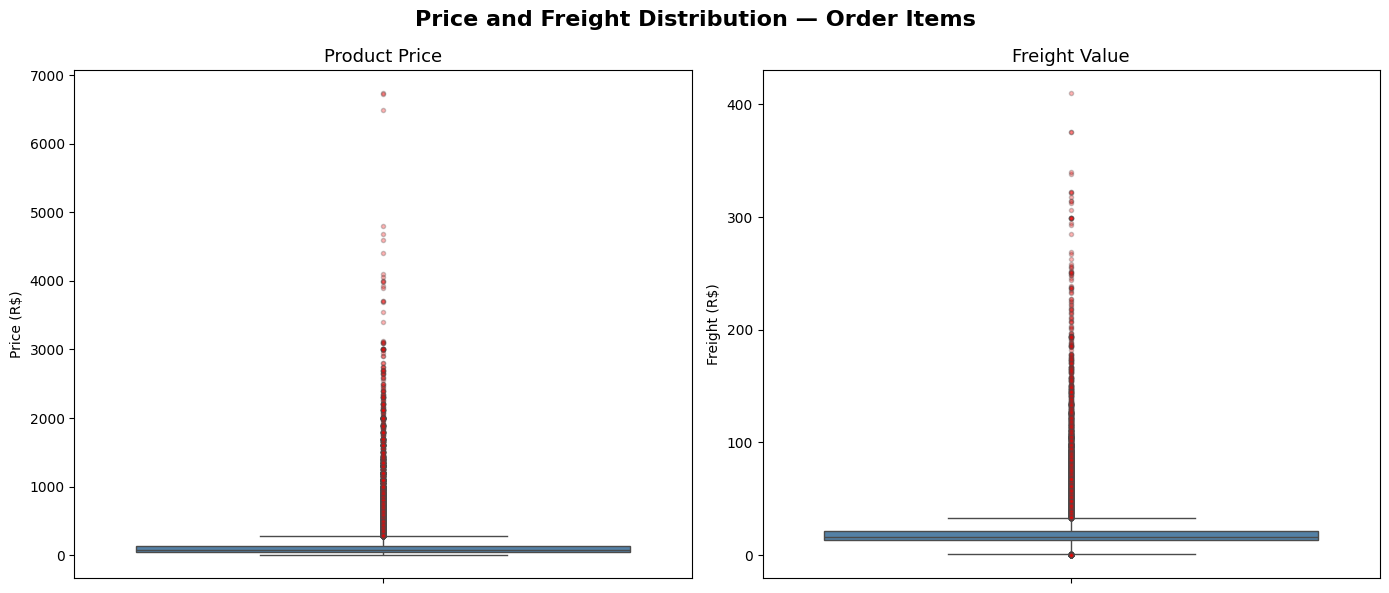

In [23]:
# Visualize price and freight_value distributions with box plots to spot extreme outliers before deciding on cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Price and Freight Distribution — Order Items',
             fontsize=16, fontweight='bold')

sns.boxplot(
    y=order_items['price'],
    ax=axes[0],
    color='steelblue',
    flierprops=dict(marker='o', markerfacecolor='red',
                    markersize=3, alpha=0.3)
)
axes[0].set_title('Product Price', fontsize=13)
axes[0].set_ylabel('Price (R$)')

sns.boxplot(
    y=order_items['freight_value'],
    ax=axes[1],
    color='steelblue',
    flierprops=dict(marker='o', markerfacecolor='red',
                    markersize=3, alpha=0.3)
)
axes[1].set_title('Freight Value', fontsize=13)
axes[1].set_ylabel('Freight (R$)')

plt.tight_layout()
plt.show()

In [24]:
# Check for suspicious values: zero freight (free shipping), freight exceeding price, and extreme low/high prices
print("SUSPICIOUS VALUES CHECK")
print('\n')
print(f"Freight = 0 (free shipping):  {(order_items['freight_value'] == 0).sum()}")
print(f"Freight > price:              {(order_items['freight_value'] > order_items['price']).sum()}")
print(f"Price < 1st percentile:       {(order_items['price'] < order_items['price'].quantile(0.01)).sum()}")
print(f"Price > 99th percentile:      {(order_items['price'] > order_items['price'].quantile(0.99)).sum()}")
print(f"Freight > 99th percentile:    {(order_items['freight_value'] > order_items['freight_value'].quantile(0.99)).sum()}")

SUSPICIOUS VALUES CHECK


Freight = 0 (free shipping):  383
Freight > price:              4124
Price < 1st percentile:       1080
Price > 99th percentile:      1117
Freight > 99th percentile:    1124


In [25]:
# Build order_items_clean — convert shipping_limit_date to datetime and engineer freight_ratio
# freight_ratio = freight_value / price is the primary independent variable for Q1
# Also flag is_free_shipping and freight_exceeds_price for later use as regression features
order_items_clean = order_items.copy()

order_items_clean['shipping_limit_date'] = pd.to_datetime(
    order_items_clean['shipping_limit_date']
)

order_items_clean['freight_ratio'] = (
    order_items_clean['freight_value'] /
    order_items_clean['price']
).replace([float('inf'), -float('inf')], None)

order_items_clean['freight_exceeds_price'] = (
    order_items_clean['freight_value'] > order_items_clean['price']
)

order_items_clean['is_free_shipping'] = (
    order_items_clean['freight_value'] == 0
)

print("Columns added successfully")
print('\n')
print(f"Data types after cleaning:")
print(order_items_clean.dtypes)

Columns added successfully


Data types after cleaning:
order_id                         object
order_item_id                     int64
product_id                       object
seller_id                        object
shipping_limit_date      datetime64[ns]
price                           float64
freight_value                   float64
freight_ratio                   float64
freight_exceeds_price              bool
is_free_shipping                   bool
dtype: object


In [26]:
# Final verification of order_items_clean — check freight_ratio stats and free-shipping / exceeds-price flag counts
print("ORDER ITEMS — AFTER CLEANING")
print(f"Shape: {order_items_clean.shape}")

print('\n')
print(f"Freight ratio stats:")
display(order_items_clean['freight_ratio'].describe().round(3))

print('\n')
print(f"Free shipping:         {order_items_clean['is_free_shipping'].sum()} ({round(order_items_clean['is_free_shipping'].sum() / len(order_items_clean) * 100, 2)}%)")
print(f"Freight exceeds price: {order_items_clean['freight_exceeds_price'].sum()} ({round(order_items_clean['freight_exceeds_price'].sum() / len(order_items_clean) * 100, 2)}%)")

print('\n')
print(f"Null counts:")
print(order_items_clean.isnull().sum())

ORDER ITEMS — AFTER CLEANING
Shape: (112650, 10)


Freight ratio stats:


count    112650.000
mean          0.321
std           0.350
min           0.000
25%           0.134
50%           0.231
75%           0.393
max          26.235
Name: freight_ratio, dtype: float64



Free shipping:         383 (0.34%)
Freight exceeds price: 4124 (3.66%)


Null counts:
order_id                 0
order_item_id            0
product_id               0
seller_id                0
shipping_limit_date      0
price                    0
freight_value            0
freight_ratio            0
freight_exceeds_price    0
is_free_shipping         0
dtype: int64


### 2.5 Order Payments Table

Some orders use multiple payment methods (e.g., partial voucher + credit card), creating multiple rows per `order_id`. Two genuine data quality issues were found:
- 3 rows with `payment_type = 'not_defined'` → dropped
- 2 credit card rows with `payment_installments = 0` → fixed to 1 (minimum valid value)

**Important:** We fix the installments value rather than dropping the row, to preserve valid `payment_value` data for orders that were confirmed delivered.


In [27]:
# Profile order_payments before cleaning — some orders use multiple payment methods, so order_id is not unique here
print("ORDER PAYMENTS — BEFORE CLEANING")
print(f"Shape: {order_payments.shape}")
print('\n')
print(f"Data types:")
print(order_payments.dtypes)
print('\n')
print(f"Unique order_ids: {order_payments['order_id'].nunique()}")
print('\n')
print(f"Payment type distribution:")
print(order_payments['payment_type'].value_counts())
print('\n')
print(f"Orders with multiple payment methods:")
multi_payments = order_payments['order_id'].value_counts()
print(multi_payments.value_counts().sort_index())
print('\n')
print(f"Null counts:")
print(order_payments.isnull().sum())
print('\n')
print(f"Payment stats:")
display(order_payments[['payment_installments', 'payment_value']].describe().round(2))

ORDER PAYMENTS — BEFORE CLEANING
Shape: (103886, 5)


Data types:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


Unique order_ids: 99440


Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


Orders with multiple payment methods:
count
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64


Null counts:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Payment stats:


,payment_installments,payment_value
count,103886.00,103886.00
mean,2.85,154.10
std,2.69,217.49
min,0.00,0.00
25%,1.00,56.79
50%,1.00,100.00
75%,4.00,171.84
max,24.00,13664.08


In [28]:
# Check for suspicious values: payment_type = 'not_defined' and payment_installments = 0 (both are data errors)
print("SUSPICIOUS VALUES CHECK")

print('\n')
print(f"Payment type = 'not_defined':")
display(order_payments[order_payments['payment_type'] == 'not_defined'])

print('\n')
print(f"Payment installments = 0:")
print(f"Count: {(order_payments['payment_installments'] == 0).sum()}")
display(order_payments[order_payments['payment_installments'] == 0].head(5))

print('\n')
print(f"Payment value = 0:")
print(f"Count: {(order_payments['payment_value'] == 0).sum()}")
display(order_payments[order_payments['payment_value'] == 0].head(5))

SUSPICIOUS VALUES CHECK


Payment type = 'not_defined':


,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0




Payment installments = 0:
Count: 2


,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94




Payment value = 0:
Count: 9


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0


In [29]:
# Build order_payments_clean — drop the 3 'not_defined' rows and fix installments=0 to 1 for credit card payments
# Fixing rather than dropping preserves valid payment_value data for orders that were confirmed delivered
before_count = len(order_payments)

order_payments_clean = order_payments[
    order_payments['payment_type'] != 'not_defined'
].copy()

order_payments_clean.loc[
    (order_payments_clean['payment_installments'] == 0) &
    (order_payments_clean['payment_type'] == 'credit_card'),
    'payment_installments'
] = 1

after_count = len(order_payments_clean)

print("ORDER PAYMENTS — AFTER CLEANING")
print(f"Before: {before_count}")
print(f"After:  {after_count}")
print(f"Rows removed: {before_count - after_count}")

print('\n')
print(f"Payment type distribution:")
print(order_payments_clean['payment_type'].value_counts())

print('\n')
print(f"Installments = 0 remaining: {(order_payments_clean['payment_installments'] == 0).sum()}")
print(f"not_defined remaining:      {(order_payments_clean['payment_type'] == 'not_defined').sum()}")

print('\n')
print(f"Null counts:")
print(order_payments_clean.isnull().sum())

ORDER PAYMENTS — AFTER CLEANING
Before: 103886
After:  103883
Rows removed: 3


Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: count, dtype: int64


Installments = 0 remaining: 0
not_defined remaining:      0


Null counts:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


### 2.6 Customers, Sellers, and Category Translation

A first pass over all three lookup tables confirms they're already clean — zero nulls, zero duplicates.


In [30]:
# Profile customers, sellers, and category_translation — all three come back clean with zero nulls and zero duplicates
for name, df in [('customers', customers),
                 ('sellers', sellers),
                 ('category_translation', category_translation)]:
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}")
    print(f"Null counts:")
    print(df.isnull().sum())
    print(f"Duplicates: {df.duplicated().sum()}")
    display(df.head(2))
    print('\n')

CUSTOMERS
Shape: (99441, 5)
Null counts:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicates: 0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP




SELLERS
Shape: (3095, 4)
Null counts:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
Duplicates: 0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP




CATEGORY_TRANSLATION
Shape: (71, 2)
Null counts:
product_category_name            0
product_category_name_english    0
dtype: int64
Duplicates: 0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


### 2.7 Products Table

Products has a small number of zero-value dimension fields (weight, length, height, width) that are physically impossible and need imputing, plus a handful of missing category names. Once cleaned, 2 Portuguese category names (`pc_gamer`, `portateis_cozinha_e_preparadores_de_alimentos`) and the artificially created `unknown` category turn out to be missing from `category_translation` and are added back manually just below.


In [31]:
# Profile the products table before cleaning — check dtypes, nulls, and duplicate product_ids
print("PRODUCTS — BEFORE CLEANING")
print('\n')
print(f"Shape: {products.shape}")
print('\n')

print(f"Data types:")
print(products.dtypes)
print('\n')

print(f"Unique product_ids: {products['product_id'].nunique()}")
print(f"Duplicate product_ids: {products['product_id'].duplicated().sum()}")
print('\n')

print(f"Null counts:")
null_counts = products.isnull().sum()
null_pct = (products.isnull().sum() / len(products) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
display(null_df[null_df['Null Count'] > 0])
print('\n')

print(f"Category distribution (top 10):")
print(products['product_category_name'].value_counts().head(10))
print('\n')

print(f"Unique categories: {products['product_category_name'].nunique()}")
print('\n')

print(f"Dimension stats:")
display(products[['product_weight_g', 'product_length_cm',
                   'product_height_cm', 'product_width_cm']].describe().round(2))
print('\n')

print(f"Sample:")
display(products.head(5))

PRODUCTS — BEFORE CLEANING


Shape: (32951, 9)


Data types:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


Unique product_ids: 32951
Duplicate product_ids: 0


Null counts:


,Null Count,Null %
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01




Category distribution (top 10):
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64


Unique categories: 73


Dimension stats:


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.00,32949.00,32949.00,32949.00
mean,2276.47,30.82,16.94,23.20
std,4282.04,16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00




Sample:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [32]:
# Check for suspicious values: zero-value product dimensions (weight, length, height, width) by category
print("SUSPICIOUS VALUES CHECK — PRODUCTS")
print('\n')

print("ZERO VALUE CHECK — ALL DIMENSIONS")
for col in ['product_weight_g', 'product_length_cm', 
            'product_height_cm', 'product_width_cm']:
    zero_count = (products[col] == 0).sum()
    print(f"{col}: {zero_count} rows with 0 value")
print('\n')

print(f"Category mismatch check:")
product_categories = set(products['product_category_name'].dropna().unique())
translation_categories = set(category_translation['product_category_name'].unique())
missing_translation = product_categories - translation_categories
print(f"Categories in products but missing translation: {missing_translation}")
print('\n')

print(f"Products affected by missing translation:")
affected = products[products['product_category_name'].isin(missing_translation)]
print(f"Count: {len(affected)}")
display(affected.head(5))

SUSPICIOUS VALUES CHECK — PRODUCTS


ZERO VALUE CHECK — ALL DIMENSIONS
product_weight_g: 4 rows with 0 value
product_length_cm: 0 rows with 0 value
product_height_cm: 0 rows with 0 value
product_width_cm: 0 rows with 0 value


Category mismatch check:
Categories in products but missing translation: {'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}


Products affected by missing translation:
Count: 13


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1628,0105b5323d24fc655f73052694dbbb3a,pc_gamer,59.0,621.0,4.0,2839.0,19.0,16.0,18.0
5821,6fd83eb3e0799b775e4f946bd66657c0,portateis_cozinha_e_preparadores_de_alimentos,52.0,280.0,1.0,1200.0,25.0,33.0,25.0
7325,5d923ead886c44b86845f69e50520c3e,portateis_cozinha_e_preparadores_de_alimentos,58.0,284.0,1.0,1200.0,25.0,33.0,25.0
7478,6727051471a0fc4a0e7737b57bff2549,pc_gamer,60.0,1532.0,3.0,650.0,16.0,22.0,20.0
8819,bed164d9d628cf0593003389c535c6e0,portateis_cozinha_e_preparadores_de_alimentos,54.0,382.0,2.0,850.0,30.0,21.0,22.0


In [33]:
# Build products_clean — fill missing category names with 'unknown' and impute zero-weight rows using the category median
products_clean = products.copy()

products_clean['product_category_name'] = products_clean['product_category_name'].fillna('unknown')

zero_weight_idx = products_clean[products_clean['product_weight_g'] == 0].index
for idx in zero_weight_idx:
    category = products_clean.loc[idx, 'product_category_name']
    category_median = products_clean[
        (products_clean['product_category_name'] == category) &
        (products_clean['product_weight_g'] > 0)
    ]['product_weight_g'].median()
    products_clean.loc[idx, 'product_weight_g'] = category_median

dimension_cols = ['product_weight_g', 'product_length_cm',
                   'product_height_cm', 'product_width_cm']

for col in dimension_cols:
    products_clean[col] = products_clean.groupby('product_category_name')[col].transform(
        lambda x: x.fillna(x.median())
    )

for col in dimension_cols:
    products_clean[col] = products_clean[col].fillna(products_clean[col].median())

products_clean['product_photos_qty'] = products_clean['product_photos_qty'].fillna(
    products_clean['product_photos_qty'].min()
)

products_clean['product_name_lenght'] = products_clean['product_name_lenght'].fillna(
    products_clean['product_name_lenght'].median()
)
products_clean['product_description_lenght'] = products_clean['product_description_lenght'].fillna(
    products_clean['product_description_lenght'].median()
)

print("PRODUCTS — CLEANING COMPLETE")
print(f"Shape: {products_clean.shape}")
print('\n')
print(f"Zero weight remaining: {(products_clean['product_weight_g'] == 0).sum()}")
print('\n')
print(f"Null counts:")
print(products_clean.isnull().sum())

PRODUCTS — CLEANING COMPLETE
Shape: (32951, 9)


Zero weight remaining: 0


Null counts:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [34]:
# Final verification of products_clean — confirm zero nulls, zero impossible weights, and correct dimension ranges
print("PRODUCTS CLEAN — FINAL VERIFICATION")
print(f"\nShape: {products_clean.shape}")
print('\n')

print(f"Data types:")
print(products_clean.dtypes)
print('\n')

print(f"Null counts:")
print(products_clean.isnull().sum())
print('\n')

print(f"Duplicate product_ids: {products_clean['product_id'].duplicated().sum()}")
print('\n')

print(f"Category 'unknown' count: {(products_clean['product_category_name'] == 'unknown').sum()}")
print('\n')

print(f"Zero weight remaining: {(products_clean['product_weight_g'] == 0).sum()}")
print('\n')

print(f"Dimension stats after cleaning:")
display(products_clean[['product_weight_g', 'product_length_cm',
                         'product_height_cm', 
                         'product_width_cm']].describe().round(2))
print('\n')

print(f"Metadata stats after cleaning:")
display(products_clean[['product_name_lenght', 'product_description_lenght',
                         'product_photos_qty']].describe().round(2))
print('\n')

print(f"Sample:")
display(products_clean.head(5))

PRODUCTS CLEAN — FINAL VERIFICATION

Shape: (32951, 9)


Data types:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


Null counts:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


Duplicate product_ids: 0


Category 'unknown' count: 610


Zero weight remaining: 0


Dimension stats after cleaning:


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.00,32951.00,32951.00,32951.00
mean,2276.53,30.81,16.94,23.20
std,4281.87,16.91,13.64,12.08
min,2.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00




Metadata stats after cleaning:


,product_name_lenght,product_description_lenght,product_photos_qty
count,32951.00,32951.00,32951.00
mean,48.52,768.23,2.17
std,10.16,629.66,1.73
min,5.00,4.00,1.00
25%,42.00,344.00,1.00
50%,51.00,595.00,1.00
75%,57.00,961.00,3.00
max,76.00,3992.00,20.00




Sample:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [35]:
# Add 3 missing rows to category_translation: pc_gamer, kitchen portables, and the artificially created 'unknown' category
# This ensures every product category in products_clean has a corresponding English translation
category_translation_clean = category_translation.copy()

missing_rows = pd.DataFrame({
    'product_category_name': [
        'pc_gamer', 
        'portateis_cozinha_e_preparadores_de_alimentos',
        'unknown'
    ],
    'product_category_name_english': [
        'gaming_pc', 
        'kitchen_portables_food_prep',
        'unknown'
    ]
})

category_translation_clean = pd.concat(
    [category_translation_clean, missing_rows],
    ignore_index=True
)

print("CATEGORY TRANSLATION — FINAL")
print(f"Shape before: {category_translation.shape}")
print(f"Shape after:  {category_translation_clean.shape}")
print('\n')

product_categories = set(products_clean['product_category_name'].unique())
translation_categories = set(category_translation_clean['product_category_name'].unique())
still_missing = product_categories - translation_categories

print(f"Categories still missing translation: {still_missing if still_missing else 'None — fully covered'}")
print('\n')

print(f"Duplicate categories: {category_translation_clean['product_category_name'].duplicated().sum()}")
print('\n')

print(f"Sample of added rows:")
display(category_translation_clean.tail(3))

CATEGORY TRANSLATION — FINAL
Shape before: (71, 2)
Shape after:  (74, 2)


Categories still missing translation: None — fully covered


Duplicate categories: 0


Sample of added rows:


,product_category_name,product_category_name_english
71,pc_gamer,gaming_pc
72,portateis_cozinha_e_preparadores_de_alimentos,kitchen_portables_food_prep
73,unknown,unknown


---
## Phase 3 — Master Analytical Table

All 9 cleaned tables are joined into a single master analytical table at **item level** (one row per order-item). This design preserves seller and product granularity needed for Q2 while enabling order-level aggregation for Q1.

### Join Sequence
| Join | Left Table | Right Table | Key | Type |
|---|---|---|---|---|
| 1 | orders_clean | order_items_clean | order_id | inner |
| 2 | master | products_clean | product_id | left |
| 3 | master | category_translation_clean | product_category_name | left |
| 4 | master | sellers | seller_id | left |
| 5 | master | customers | customer_id | left |
| 6 | master | reviews_clean | order_id | left |
| 7 | master | payments_agg | order_id | left |
| 8 | master | geo_clean (seller) | seller_zip_code_prefix | left |
| 9 | master | geo_clean (customer) | customer_zip_code_prefix | left |

Joins 8 and 9 attach seller and customer coordinates so a haversine `shipping_distance_km` can be calculated — a distance-based logistics feature used throughout Q1 and Q2.

**Final shape: 105,363 rows × 50 columns**

> **Note:** 700 rows have `review_score = null` — these are legitimately delivered orders where the customer never submitted a review. They are retained in master and filtered out at analysis time whenever review_score is required.


In [36]:
# Join 1: orders_clean + order_items_clean on order_id — inner join creates the item-level master table
# Row count exceeds orders (92,315 orders -> 105,363 rows) because multi-item orders create one row per item
master = orders_clean.merge(
    order_items_clean,
    on='order_id',
    how='inner'
)

print("JOIN 1 — Orders + Order Items")
print(f"Orders_clean shape:     {orders_clean.shape}")
print(f"Order_items_clean shape: {order_items_clean.shape}")
print(f"Master shape after join: {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 1 — Orders + Order Items
Orders_clean shape:     (92315, 13)
Order_items_clean shape: (112650, 10)
Master shape after join: (105363, 22)


Null counts:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
freight_exceeds_price            0
is_free_shipping                 0
dtype: int64


In [37]:
# Join 2: add product information — left join on product_id, row count unchanged (many-to-one join)
before_shape = master.shape

master = master.merge(
    products_clean,
    on='product_id',
    how='left'
)

print("JOIN 2 — Master + Products")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 2 — Master + Products
Master shape before: (105363, 22)
Master shape after:  (105363, 30)


Null counts:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
freight_exceeds_price            0
is_free_shipping                 0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_

In [38]:
# Join 3: add English category translations — left join on product_category_name, row count unchanged
before_shape = master.shape

master = master.merge(
    category_translation_clean,
    on='product_category_name',
    how='left'
)

print("JOIN 3 — Master + Category Translation")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts (complete):")
print(master.isnull().sum())

JOIN 3 — Master + Category Translation
Master shape before: (105363, 30)
Master shape after:  (105363, 31)


Null counts (complete):
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
freight_exceeds_price            0
is_free_shipping                 0
product_category_name            0
product_name_lenght              0
product_description_lenght 

In [39]:
# Join 4: add seller city and state — left join on seller_id, row count unchanged (seller_id is unique per row)
before_shape = master.shape

master = master.merge(
    sellers,
    on='seller_id',
    how='left'
)

print("JOIN 4 — Master + Sellers")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 4 — Master + Sellers
Master shape before: (105363, 31)
Master shape after:  (105363, 34)


Null counts:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
freight_exceeds_price            0
is_free_shipping                 0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_q

In [40]:
# Join 5: add customer location — left join on customer_id, row count unchanged (customer_id is unique per row)
before_shape = master.shape

master = master.merge(
    customers,
    on='customer_id',
    how='left'
)

print("JOIN 5 — Master + Customers")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 5 — Master + Customers
Master shape before: (105363, 34)
Master shape after:  (105363, 38)


Null counts:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
promise_gap_days                 0
actual_delivery_days             0
carrier_pickup_days              0
delivery_to_customer_days        0
delivery_status                  0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
freight_exceeds_price            0
is_free_shipping                 0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos

In [41]:
# Join 6: add review scores — left join on order_id, 700 nulls retained for orders with no submitted review
# Nulls are deliberately kept here — they get filtered out at analysis time when review_score is required
before_shape = master.shape

master = master.merge(
    reviews_clean[['order_id', 'review_score', 
                   'review_creation_date', 
                   'review_answer_timestamp']],
    on='order_id',
    how='left'
)

print("JOIN 6 — Master + Reviews")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 6 — Master + Reviews
Master shape before: (105363, 38)
Master shape after:  (105363, 41)


Null counts:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
promise_gap_days                   0
actual_delivery_days               0
carrier_pickup_days                0
delivery_to_customer_days          0
delivery_status                    0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
freight_ratio                      0
freight_exceeds_price              0
is_free_shipping                   0
product_category_name              0
product_name_lenght                0
pro

In [42]:
# Aggregate payments to order level before joining — order_id is not unique in payments (multiple methods possible)
# Sum payment_value, take max installments, count unique payment types, and identify the primary method
payments_agg = order_payments_clean.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_methods_count=('payment_type', 'nunique'),
    primary_payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

print("PAYMENTS AGGREGATED TO ORDER LEVEL")
print(f"Shape: {payments_agg.shape}")
print(f"\nUnique order_ids: {payments_agg['order_id'].nunique()}")
print(f"\nSample:")
display(payments_agg.head(5))

PAYMENTS AGGREGATED TO ORDER LEVEL
Shape: (99437, 5)

Unique order_ids: 99437

Sample:


,order_id,total_payment_value,max_installments,payment_methods_count,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [43]:
# Join 7: add aggregated payment data — left join on order_id, 0 nulls confirms the installment fix worked
before_shape = master.shape

master = master.merge(
    payments_agg,
    on='order_id',
    how='left'
)

print("JOIN 7 — Master + Payments")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 7 — Master + Payments
Master shape before: (105363, 41)
Master shape after:  (105363, 45)


Null counts:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
promise_gap_days                   0
actual_delivery_days               0
carrier_pickup_days                0
delivery_to_customer_days          0
delivery_status                    0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
freight_ratio                      0
freight_exceeds_price              0
is_free_shipping                   0
product_category_name              0
product_name_lenght                0
pr

In [44]:
# Join 8: attach seller latitude/longitude — left join geo_clean on seller_zip_code_prefix
# 242 nulls appear where a seller's zip code has no matching geolocation entry
before_shape = master.shape

master = master.merge(
    geo_clean[['geolocation_zip_code_prefix',
               'geolocation_lat',
               'geolocation_lng']].rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'geolocation_lat': 'seller_lat',
        'geolocation_lng': 'seller_lng'
    }),
    on='seller_zip_code_prefix',
    how='left'
)

print(f"JOIN 8 — Master + Seller Geo")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 8 — Master + Seller Geo
Master shape before: (105363, 45)
Master shape after:  (105363, 47)


Null counts:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
promise_gap_days                   0
actual_delivery_days               0
carrier_pickup_days                0
delivery_to_customer_days          0
delivery_status                    0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
freight_ratio                      0
freight_exceeds_price              0
is_free_shipping                   0
product_category_name              0
product_name_lenght                0


In [45]:
# Join 9: attach customer latitude/longitude — left join geo_clean on customer_zip_code_prefix
# 272 nulls appear where a customer's zip code has no matching geolocation entry
before_shape = master.shape

master = master.merge(
    geo_clean[['geolocation_zip_code_prefix',
               'geolocation_lat',
               'geolocation_lng']].rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lng'
    }),
    on='customer_zip_code_prefix',
    how='left'
)

print(f"JOIN 9 — Master + Customer Geo")
print(f"Master shape before: {before_shape}")
print(f"Master shape after:  {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

JOIN 9 — Master + Customer Geo
Master shape before: (105363, 47)
Master shape after:  (105363, 49)


Null counts:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
promise_gap_days                   0
actual_delivery_days               0
carrier_pickup_days                0
delivery_to_customer_days          0
delivery_status                    0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
freight_ratio                      0
freight_exceeds_price              0
is_free_shipping                   0
product_category_name              0
product_name_lenght                

In [46]:
# Calculate shipping_distance_km between seller and customer using the haversine formula
# Only rows with both seller and customer coordinates get a distance — 513 rows remain null and are handled later
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

mask = (
    master['seller_lat'].notnull() &
    master['customer_lat'].notnull()
)

master.loc[mask, 'shipping_distance_km'] = master[mask].apply(
    lambda row: haversine_distance(
        row['seller_lat'], row['seller_lng'],
        row['customer_lat'], row['customer_lng']
    ), axis=1
)

print(f"SHIPPING DISTANCE — CALCULATED")
print(f"Rows with valid distance: {mask.sum()}")
print(f"Rows with null distance:  {master['shipping_distance_km'].isnull().sum()}")
print(f"\nShipping distance stats (km):")
display(master['shipping_distance_km'].describe().round(2))
print(f"\nFinal master shape: {master.shape}")
print('\n')
print(f"Null counts:")
print(master.isnull().sum())

SHIPPING DISTANCE — CALCULATED
Rows with valid distance: 104850
Rows with null distance:  513

Shipping distance stats (km):


count    104850.00
mean        584.02
std         576.47
min           0.00
25%         174.24
50%         425.46
75%         777.59
max        3399.19
Name: shipping_distance_km, dtype: float64


Final master shape: (105363, 50)


Null counts:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
promise_gap_days                   0
actual_delivery_days               0
carrier_pickup_days                0
delivery_to_customer_days          0
delivery_status                    0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
freight_ratio                      0
freight_exceeds_price              0
is_free_shipping                   0
product_category_name              0
product_name_lenght                0
product_description_lenght         0
product_photos_qty        

In [47]:
# Final verification of the complete master table — 105,363 rows x 50 columns covering all 9 joins
print("MASTER TABLE — FINAL VERIFICATION")
print(f"\nShape: {master.shape}")
print('\n')

print(f"All columns:")
print(master.columns.tolist())
print('\n')

print(f"Data types:")
print(master.dtypes)
print('\n')

print(f"Null counts:")
print(master.isnull().sum())
print('\n')

print(f"Unique order_ids:    {master['order_id'].nunique()}")
print(f"Unique customer_ids: {master['customer_id'].nunique()}")
print(f"Unique seller_ids:   {master['seller_id'].nunique()}")
print(f"Unique product_ids:  {master['product_id'].nunique()}")
print('\n')

print(f"Review score distribution (excluding nulls):")
print(master['review_score'].value_counts(dropna=True).sort_index())
print('\n')

print(f"Sample:")
display(master.head(3))

MASTER TABLE — FINAL VERIFICATION

Shape: (105363, 50)


All columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'promise_gap_days', 'actual_delivery_days', 'carrier_pickup_days', 'delivery_to_customer_days', 'delivery_status', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'freight_ratio', 'freight_exceeds_price', 'is_free_shipping', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'total_payment_value', 'max_installments', 'p

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,promise_gap_days,actual_delivery_days,...,review_answer_timestamp,total_payment_value,max_installments,payment_methods_count,primary_payment_type,seller_lat,seller_lng,customer_lat,customer_lng,shipping_distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8,8,...,2017-10-12 03:43:48,38.71,1,2,voucher,-23.680729,-46.444238,-23.576983,-46.587161,18.576110
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6,13,...,2018-08-08 18:37:50,141.46,1,1,boleto,-19.807681,-43.980427,-12.177924,-44.660711,851.495069
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18,9,...,2018-08-22 19:07:58,179.12,3,1,credit_card,-21.363502,-48.229601,-16.745150,-48.514783,514.410666


In [48]:
# Save the master table as a CSV checkpoint — this is the deliverable for all downstream analysis
master.to_csv('master_analytical_table.csv', index=False)
print("Master table saved successfully")
print(f"Shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")

Master table saved successfully
Shape: (105363, 50)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'promise_gap_days', 'actual_delivery_days', 'carrier_pickup_days', 'delivery_to_customer_days', 'delivery_status', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'freight_ratio', 'freight_exceeds_price', 'is_free_shipping', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'total_payment_value', 'max_installments', 'payment_me

In [49]:
# Reload the saved CSV to confirm it was written correctly and the shape/columns match the in-memory table
import os
file_size = os.path.getsize('master_analytical_table.csv')
print(f"File saved: master_analytical_table.csv")
print(f"File size: {round(file_size / (1024*1024), 2)} MB")

test_load = pd.read_csv('master_analytical_table.csv')
print(f"Reload test shape: {test_load.shape}")
print(f"Columns match: {list(test_load.columns) == list(master.columns)}")
del test_load
print("Checkpoint verified successfully")

File saved: master_analytical_table.csv
File size: 61.54 MB
Reload test shape: (105363, 50)
Columns match: True
Checkpoint verified successfully


---
## Phase 4 — Exploratory Data Analysis

### Question 1: Pricing Perception vs Operational Performance

> *"Does freight cost as a percentage of product price (freight_ratio) independently predict customer review scores after controlling for delivery performance?"*

**Analytical approach:**
1. Reload the saved master table checkpoint (so analysis can run standalone without repeating Phases 1–3)
2. Descriptive statistics and distribution analysis of key Q1 variables
3. Correlation analysis (Pearson and Spearman) between freight_ratio and review_score
4. Visual comparison of review scores across freight ratio quartiles vs delivery status groups
5. Statistical hypothesis testing (ANOVA, Kruskal-Wallis, Mann-Whitney U)
6. Base multivariate regression (8 features)
7. Extended multivariate regression (15 features) to validate base model findings


In [50]:
# Reload the master table checkpoint and reparse datetime columns (CSV round-trips lose dtype information)
# Reloading from disk here means analysis can resume without rerunning all 9 cleaning steps and 9 joins
master = pd.read_csv('master_analytical_table.csv')

datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in datetime_cols:
    master[col] = pd.to_datetime(master[col], format='mixed')

print(f"Master table loaded successfully")
print(f"Shape: {master.shape}")
print("\n")
print(f"Datetime columns converted:")
for col in datetime_cols:
    print(f"  {col}: {master[col].dtype}")

Master table loaded successfully
Shape: (105363, 50)


Datetime columns converted:
  order_purchase_timestamp: datetime64[ns]
  order_approved_at: datetime64[ns]
  order_delivered_carrier_date: datetime64[ns]
  order_delivered_customer_date: datetime64[ns]
  order_estimated_delivery_date: datetime64[ns]
  shipping_limit_date: datetime64[ns]
  review_creation_date: datetime64[ns]
  review_answer_timestamp: datetime64[ns]


In [51]:
# Build q1_data — filter to rows with a review score, then engineer log-transformed and binary features
# Log transforms reduce the influence of extreme values in freight_ratio, price, and shipping_distance_km
from scipy import stats

q1_data = master[master['review_score'].notnull()].copy()

q1_data['log_freight_ratio'] = np.log1p(q1_data['freight_ratio'])
q1_data['log_price'] = np.log1p(q1_data['price'])
q1_data['log_distance'] = np.log1p(q1_data['shipping_distance_km'])

# Binary flag for late delivery
q1_data['is_late'] = (q1_data['delivery_status'] == 'late').astype(int)

print("Q1 DATA — BASIC PROFILE")
print(f"Shape: {q1_data.shape}")
print('\n')

print(f"Key variable stats:")
display(q1_data[['freight_ratio', 'price', 'freight_value',
                  'review_score', 'actual_delivery_days',
                  'promise_gap_days',
                  'shipping_distance_km']].describe().round(3))

Q1 DATA — BASIC PROFILE
Shape: (104663, 54)


Key variable stats:


,freight_ratio,price,freight_value,review_score,actual_delivery_days,promise_gap_days,shipping_distance_km
count,104663.000,104663.000,104663.000,104663.000,104663.000,104663.000,104151.000
mean,0.320,118.364,19.637,4.149,10.876,-12.782,583.930
std,0.349,178.358,15.237,1.290,6.706,8.010,576.428
min,0.000,0.850,0.000,1.000,0.000,-47.000,0.000
25%,0.134,39.900,12.930,4.000,6.000,-17.000,174.231
50%,0.231,72.900,16.140,5.000,9.000,-13.000,425.391
75%,0.393,129.990,20.870,5.000,14.000,-8.000,777.481
max,26.235,6735.000,409.680,5.000,42.000,24.000,3399.191


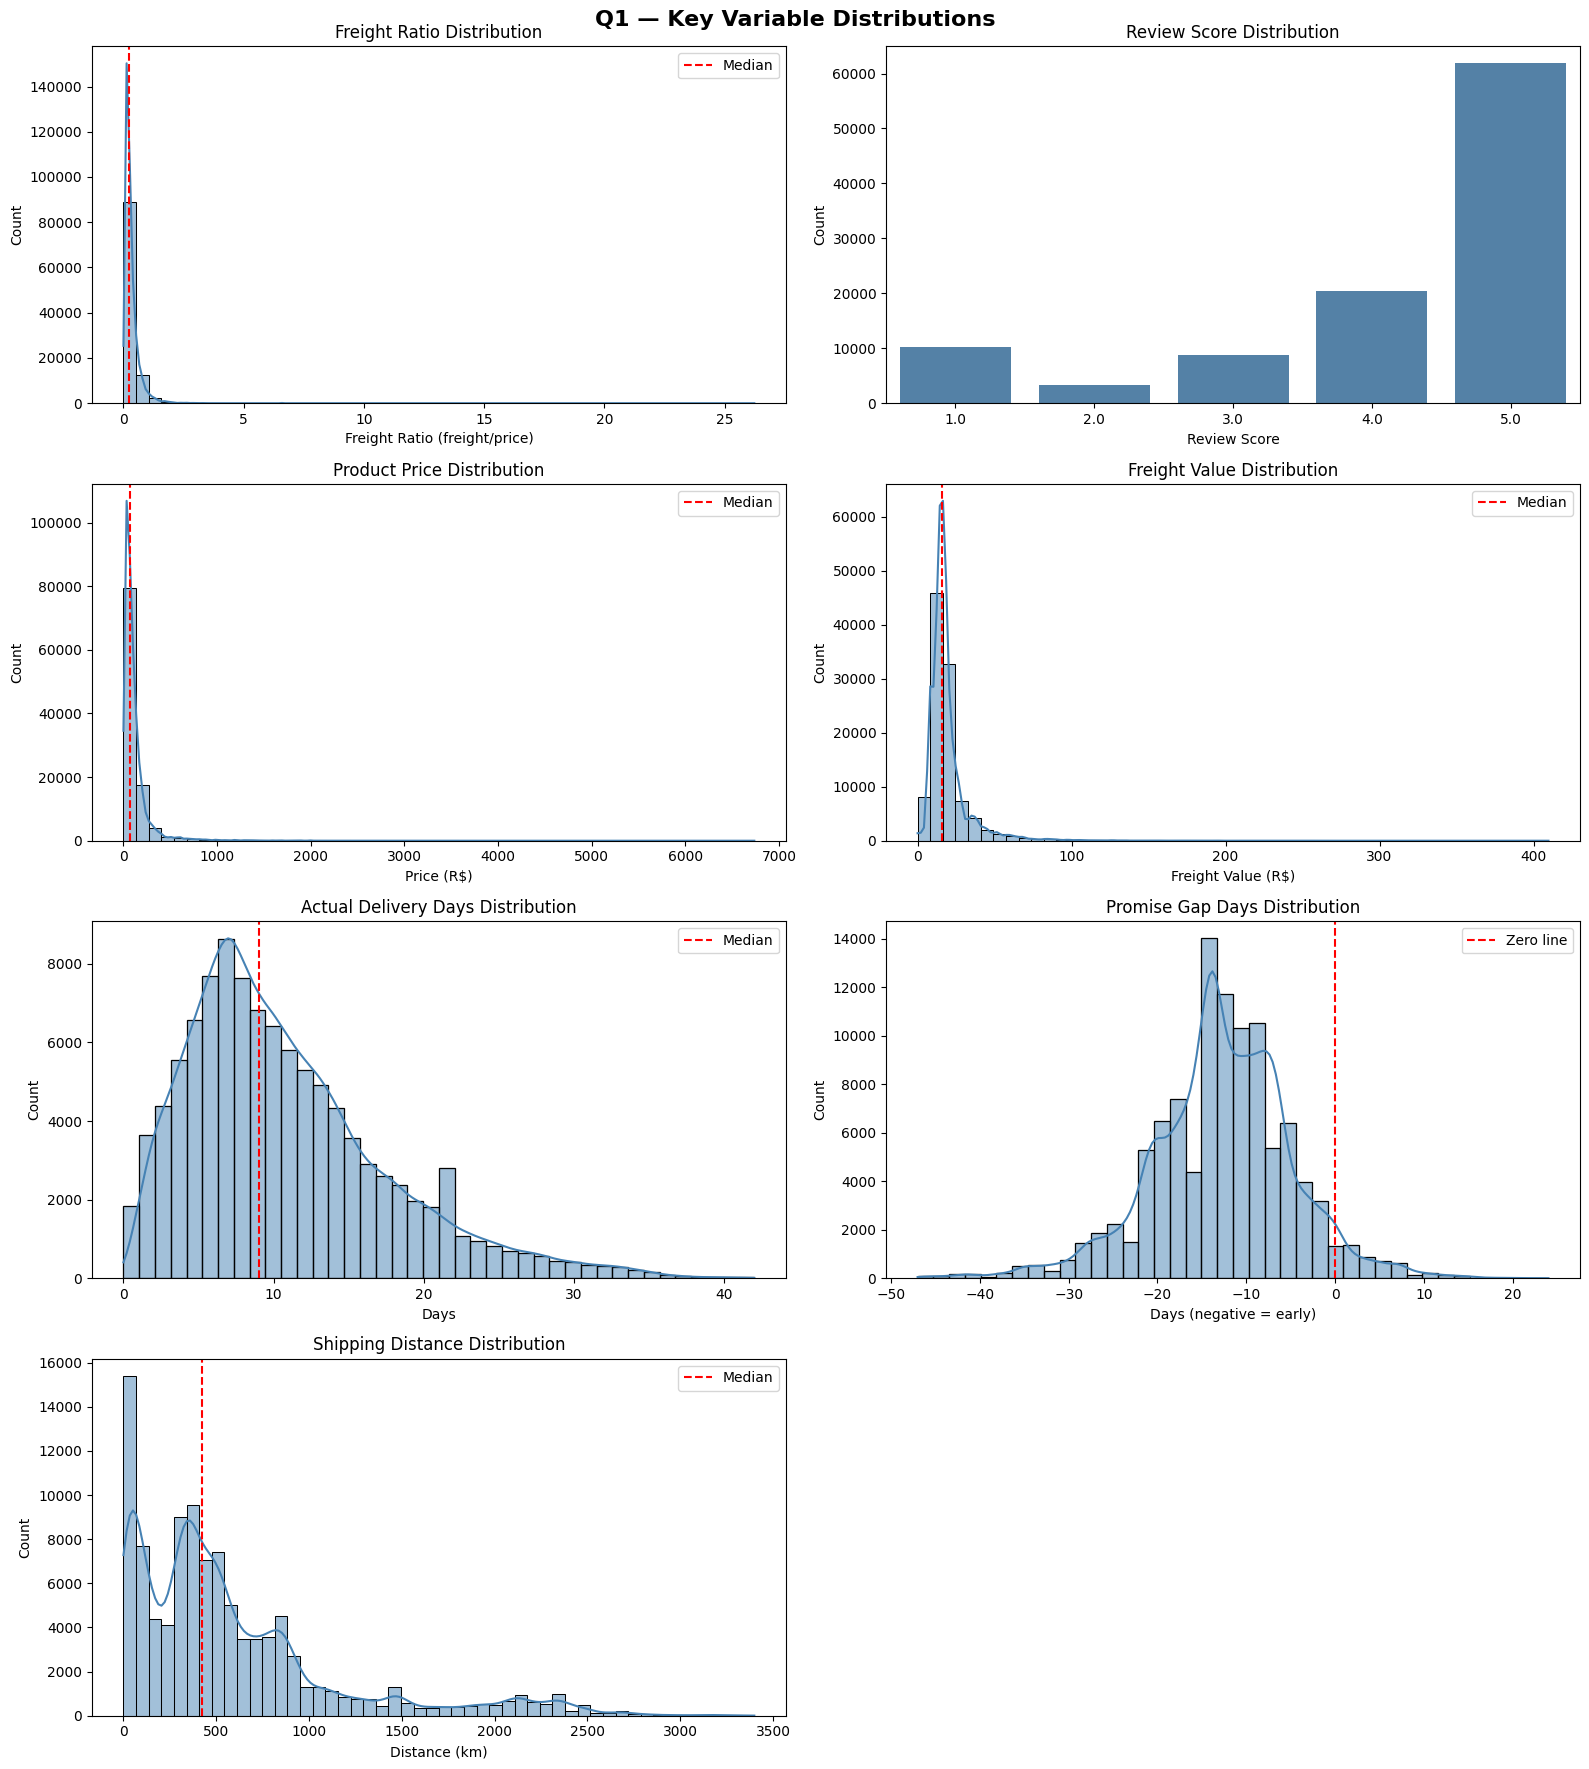

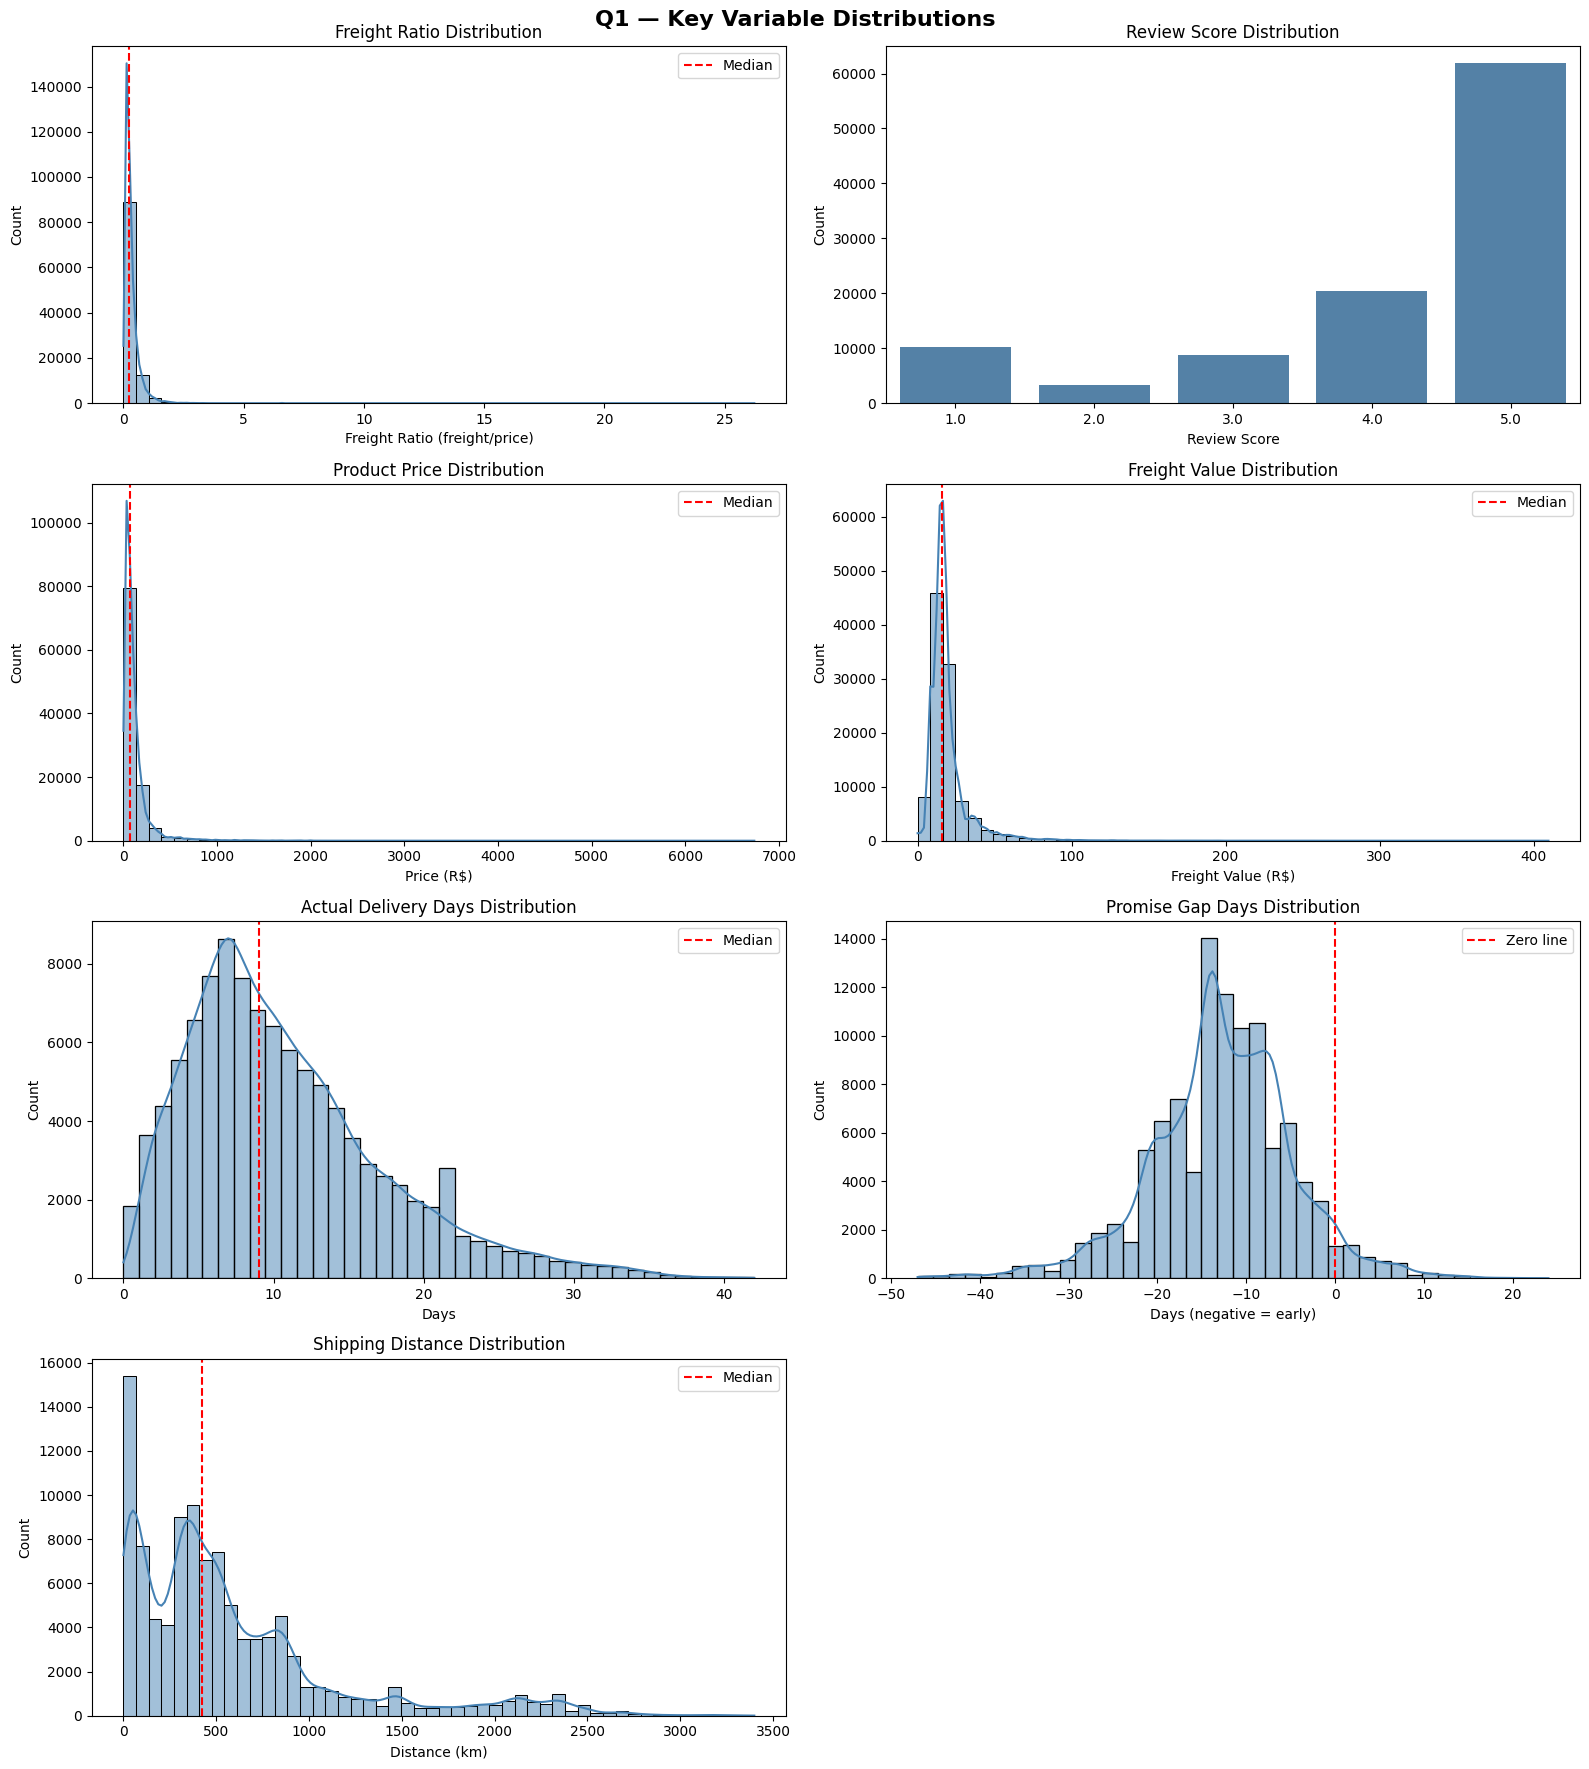

In [52]:
# Visualize the distributions of all key Q1 variables (freight ratio, review score, price, delivery timing, distance)
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle('Q1 — Key Variable Distributions',
             fontsize=16, fontweight='bold')

sns.histplot(q1_data['freight_ratio'], bins=50,
             ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Freight Ratio Distribution')
axes[0,0].set_xlabel('Freight Ratio (freight/price)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(q1_data['freight_ratio'].median(),
                   color='red', linestyle='--', label='Median')
axes[0,0].legend()

sns.countplot(x=q1_data['review_score'], ax=axes[0,1],
              color='steelblue')
axes[0,1].set_title('Review Score Distribution')
axes[0,1].set_xlabel('Review Score')
axes[0,1].set_ylabel('Count')

sns.histplot(q1_data['price'], bins=50,
             ax=axes[1,0], color='steelblue', kde=True)
axes[1,0].set_title('Product Price Distribution')
axes[1,0].set_xlabel('Price (R$)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(q1_data['price'].median(),
                   color='red', linestyle='--', label='Median')
axes[1,0].legend()

sns.histplot(q1_data['freight_value'], bins=50,
             ax=axes[1,1], color='steelblue', kde=True)
axes[1,1].set_title('Freight Value Distribution')
axes[1,1].set_xlabel('Freight Value (R$)')
axes[1,1].set_ylabel('Count')
axes[1,1].axvline(q1_data['freight_value'].median(),
                   color='red', linestyle='--', label='Median')
axes[1,1].legend()

sns.histplot(q1_data['actual_delivery_days'], bins=40,
             ax=axes[2,0], color='steelblue', kde=True)
axes[2,0].set_title('Actual Delivery Days Distribution')
axes[2,0].set_xlabel('Days')
axes[2,0].set_ylabel('Count')
axes[2,0].axvline(q1_data['actual_delivery_days'].median(),
                   color='red', linestyle='--', label='Median')
axes[2,0].legend()

sns.histplot(q1_data['promise_gap_days'], bins=40,
             ax=axes[2,1], color='steelblue', kde=True)
axes[2,1].set_title('Promise Gap Days Distribution')
axes[2,1].set_xlabel('Days (negative = early)')
axes[2,1].set_ylabel('Count')
axes[2,1].axvline(0, color='red', linestyle='--', label='Zero line')
axes[2,1].legend()

sns.histplot(q1_data['shipping_distance_km'].dropna(), bins=50,
             ax=axes[3,0], color='steelblue', kde=True)
axes[3,0].set_title('Shipping Distance Distribution')
axes[3,0].set_xlabel('Distance (km)')
axes[3,0].set_ylabel('Count')
axes[3,0].axvline(q1_data['shipping_distance_km'].median(),
                   color='red', linestyle='--', label='Median')
axes[3,0].legend()

axes[3,1].set_visible(False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle('Q1 — Key Variable Distributions',
             fontsize=16, fontweight='bold')

sns.histplot(q1_data['freight_ratio'], bins=50,
             ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Freight Ratio Distribution')
axes[0,0].set_xlabel('Freight Ratio (freight/price)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(q1_data['freight_ratio'].median(),
                   color='red', linestyle='--', label='Median')
axes[0,0].legend()

sns.countplot(x=q1_data['review_score'], ax=axes[0,1],
              color='steelblue')
axes[0,1].set_title('Review Score Distribution')
axes[0,1].set_xlabel('Review Score')
axes[0,1].set_ylabel('Count')

sns.histplot(q1_data['price'], bins=50,
             ax=axes[1,0], color='steelblue', kde=True)
axes[1,0].set_title('Product Price Distribution')
axes[1,0].set_xlabel('Price (R$)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(q1_data['price'].median(),
                   color='red', linestyle='--', label='Median')
axes[1,0].legend()

sns.histplot(q1_data['freight_value'], bins=50,
             ax=axes[1,1], color='steelblue', kde=True)
axes[1,1].set_title('Freight Value Distribution')
axes[1,1].set_xlabel('Freight Value (R$)')
axes[1,1].set_ylabel('Count')
axes[1,1].axvline(q1_data['freight_value'].median(),
                   color='red', linestyle='--', label='Median')
axes[1,1].legend()

sns.histplot(q1_data['actual_delivery_days'], bins=40,
             ax=axes[2,0], color='steelblue', kde=True)
axes[2,0].set_title('Actual Delivery Days Distribution')
axes[2,0].set_xlabel('Days')
axes[2,0].set_ylabel('Count')
axes[2,0].axvline(q1_data['actual_delivery_days'].median(),
                   color='red', linestyle='--', label='Median')
axes[2,0].legend()

sns.histplot(q1_data['promise_gap_days'], bins=40,
             ax=axes[2,1], color='steelblue', kde=True)
axes[2,1].set_title('Promise Gap Days Distribution')
axes[2,1].set_xlabel('Days (negative = early)')
axes[2,1].set_ylabel('Count')
axes[2,1].axvline(0, color='red', linestyle='--', label='Zero line')
axes[2,1].legend()

sns.histplot(q1_data['shipping_distance_km'].dropna(), bins=50,
             ax=axes[3,0], color='steelblue', kde=True)
axes[3,0].set_title('Shipping Distance Distribution')
axes[3,0].set_xlabel('Distance (km)')
axes[3,0].set_ylabel('Count')
axes[3,0].axvline(q1_data['shipping_distance_km'].median(),
                   color='red', linestyle='--', label='Median')
axes[3,0].legend()

axes[3,1].set_visible(False)

plt.tight_layout()
plt.show()

In [53]:
# Check Pearson and Spearman correlations between shipping_distance_km and the other key variables
# This confirms distance is a reasonable proxy for logistics difficulty before using it as a regression feature
print("SHIPPING DISTANCE — CORRELATION WITH KEY VARIABLES")
print('\n')

valid_mask = q1_data['shipping_distance_km'].notnull()
dist = q1_data.loc[valid_mask, 'shipping_distance_km']

for var in ['freight_ratio', 'freight_value', 'review_score', 'actual_delivery_days']:
    target = q1_data.loc[valid_mask, var]

    pearson_corr, pearson_p = stats.pearsonr(dist, target)
    spearman_corr, spearman_p = stats.spearmanr(dist, target)

    print(f"Shipping distance vs {var}:")
    print(f"  Pearson:  r={round(pearson_corr, 4)}, p={round(pearson_p, 6)}")
    print(f"  Spearman: r={round(spearman_corr, 4)}, p={round(spearman_p, 6)}")
    print('\n')

SHIPPING DISTANCE — CORRELATION WITH KEY VARIABLES


Shipping distance vs freight_ratio:
  Pearson:  r=0.1704, p=0.0
  Spearman: r=0.2052, p=0.0


Shipping distance vs freight_value:
  Pearson:  r=0.3964, p=0.0
  Spearman: r=0.637, p=0.0


Shipping distance vs review_score:
  Pearson:  r=-0.0321, p=0.0
  Spearman: r=-0.0495, p=0.0


Shipping distance vs actual_delivery_days:
  Pearson:  r=0.4714, p=0.0
  Spearman: r=0.5534, p=0.0




In [54]:
# Core Q1 correlation analysis — freight_ratio vs review_score is very weak (r = -0.036 to -0.041, though p < 0.001)
# Log-transforming freight_ratio doesn't change the correlation strength; shipping distance is similarly weak (r = -0.05)
print("Q1 — CORRELATION ANALYSIS")
print('\n')

pearson_corr, pearson_p = stats.pearsonr(
    q1_data['freight_ratio'],
    q1_data['review_score']
)
print(f"Pearson Correlation — freight_ratio vs review_score:")
print(f"  Correlation: {round(pearson_corr, 4)}")
print(f"  P-value:     {round(pearson_p, 6)}")
print('\n')

spearman_corr, spearman_p = stats.spearmanr(
    q1_data['freight_ratio'],
    q1_data['review_score']
)
print(f"Spearman Correlation — freight_ratio vs review_score:")
print(f"  Correlation: {round(spearman_corr, 4)}")
print(f"  P-value:     {round(spearman_p, 6)}")
print('\n')

log_corr, log_p = stats.spearmanr(
    q1_data['log_freight_ratio'],
    q1_data['review_score']
)
print(f"Spearman Correlation — log_freight_ratio vs review_score:")
print(f"  Correlation: {round(log_corr, 4)}")
print(f"  P-value:     {round(log_p, 6)}")
print('\n')

dist_corr, dist_p = stats.spearmanr(
    q1_data['shipping_distance_km'].dropna(),
    q1_data.loc[q1_data['shipping_distance_km'].notnull(), 'review_score']
)
print(f"Spearman Correlation — shipping_distance_km vs review_score:")
print(f"  Correlation: {round(dist_corr, 4)}")
print(f"  P-value:     {round(dist_p, 6)}")

Q1 — CORRELATION ANALYSIS


Pearson Correlation — freight_ratio vs review_score:
  Correlation: -0.0414
  P-value:     0.0


Spearman Correlation — freight_ratio vs review_score:
  Correlation: -0.036
  P-value:     0.0


Spearman Correlation — log_freight_ratio vs review_score:
  Correlation: -0.036
  P-value:     0.0


Spearman Correlation — shipping_distance_km vs review_score:
  Correlation: -0.0495
  P-value:     0.0


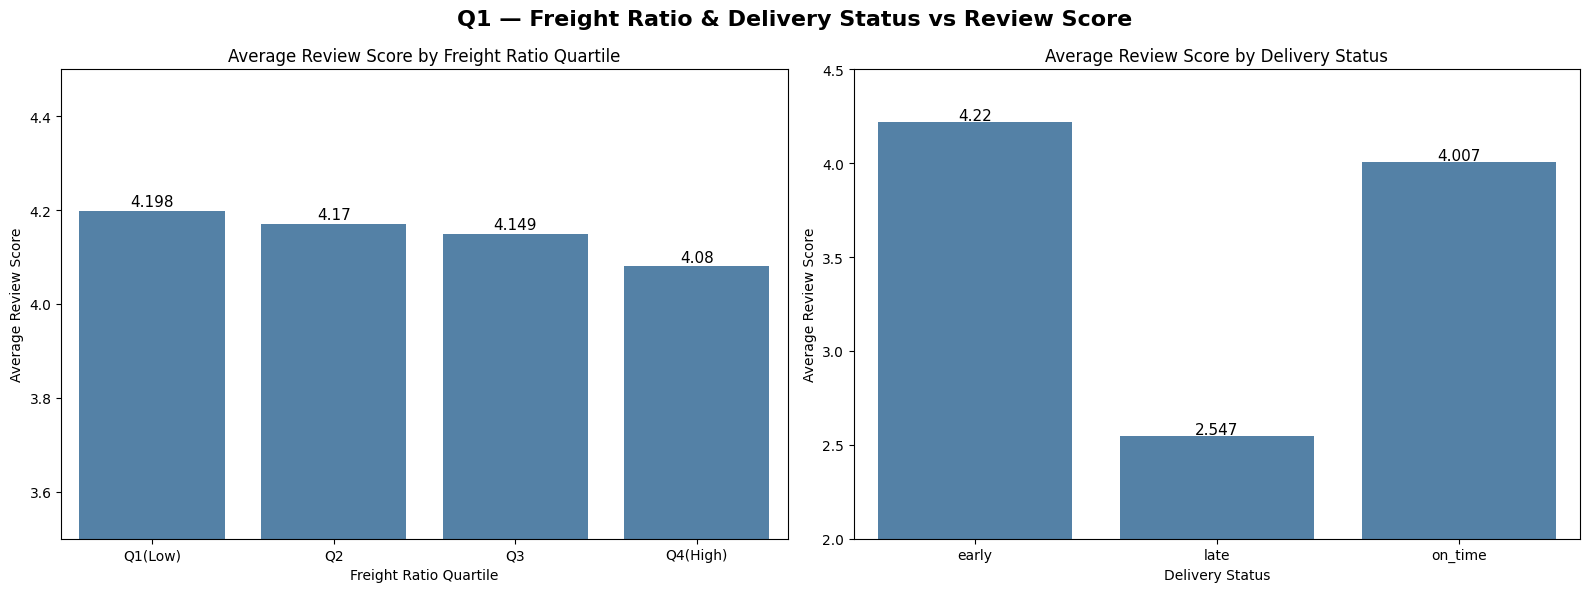



Average review score by freight ratio quartile:
freight_ratio_quartile
Q1(Low)     4.198
Q2          4.170
Q3          4.149
Q4(High)    4.080
Name: review_score, dtype: float64


Average review score by delivery status:
delivery_status
early      4.220
late       2.547
on_time    4.007
Name: review_score, dtype: float64


In [55]:
# Compare average review score across freight ratio quartiles vs across delivery status groups
# Delivery status shows a far larger spread in review score than freight ratio quartile does
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q1 — Freight Ratio & Delivery Status vs Review Score',
             fontsize=16, fontweight='bold')

q1_data['freight_ratio_quartile'] = pd.qcut(
    q1_data['freight_ratio'],
    q=4,
    labels=['Q1(Low)', 'Q2', 'Q3', 'Q4(High)']
)

quartile_means = q1_data.groupby(
    'freight_ratio_quartile', observed=True
)['review_score'].mean().round(3)

sns.barplot(x=quartile_means.index, y=quartile_means.values,
            ax=axes[0], color='steelblue')
axes[0].set_title('Average Review Score by Freight Ratio Quartile')
axes[0].set_xlabel('Freight Ratio Quartile')
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(3.5, 4.5)
for i, v in enumerate(quartile_means.values):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontsize=11)

delivery_means = q1_data.groupby(
    'delivery_status'
)['review_score'].mean().round(3)

sns.barplot(x=delivery_means.index, y=delivery_means.values,
            ax=axes[1], color='steelblue')
axes[1].set_title('Average Review Score by Delivery Status')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Average Review Score')
axes[1].set_ylim(2.0, 4.5)
for i, v in enumerate(delivery_means.values):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print('\n')
print("Average review score by freight ratio quartile:")
print(quartile_means)
print('\n')
print("Average review score by delivery status:")
print(delivery_means)

In [56]:
# Formal hypothesis testing — ANOVA and Kruskal-Wallis across freight ratio quartiles, Mann-Whitney U for early vs late delivery
# All three tests are significant (p < 0.001), but statistical significance alone doesn't tell us about effect size
print("Q1 — HYPOTHESIS TESTING")
print('\n')

q1_groups = [
    q1_data[q1_data['freight_ratio_quartile'] == q]['review_score']
    for q in ['Q1(Low)', 'Q2', 'Q3', 'Q4(High)']
]

anova_stat, anova_p = stats.f_oneway(*q1_groups)
print("Test 1 — One-Way ANOVA")
print("H0: Average review score is equal across all freight ratio quartiles")
print("H1: At least one quartile has a significantly different review score")
print(f"\n  F-statistic: {round(anova_stat, 4)}")
print(f"  P-value:     {round(anova_p, 6)}")
print(f"  Result: {'REJECT H0 — significant difference exists' if anova_p < 0.05 else 'FAIL TO REJECT H0'}")
print('\n')

early = q1_data[q1_data['delivery_status'] == 'early']['review_score']
late = q1_data[q1_data['delivery_status'] == 'late']['review_score']

mw_stat, mw_p = stats.mannwhitneyu(early, late, alternative='greater')
print("Test 2 — Mann-Whitney U Test")
print("H0: Early delivery review scores are NOT higher than late delivery scores")
print("H1: Early delivery review scores ARE significantly higher than late delivery scores")
print(f"\n  U-statistic: {round(mw_stat, 4)}")
print(f"  P-value:     {round(mw_p, 6)}")
print(f"  Result: {'REJECT H0 — early deliveries get significantly higher scores' if mw_p < 0.05 else 'FAIL TO REJECT H0'}")
print('\n')

kw_stat, kw_p = stats.kruskal(*q1_groups)
print("Test 3 — Kruskal-Wallis Test (non-parametric ANOVA)")
print("H0: Review score distribution is equal across all freight ratio quartiles")
print("H1: At least one quartile has a significantly different distribution")
print(f"\n  H-statistic: {round(kw_stat, 4)}")
print(f"  P-value:     {round(kw_p, 6)}")
print(f"  Result: {'REJECT H0 — significant difference exists' if kw_p < 0.05 else 'FAIL TO REJECT H0'}")

Q1 — HYPOTHESIS TESTING


Test 1 — One-Way ANOVA
H0: Average review score is equal across all freight ratio quartiles
H1: At least one quartile has a significantly different review score

  F-statistic: 40.181
  P-value:     0.0
  Result: REJECT H0 — significant difference exists


Test 2 — Mann-Whitney U Test
H0: Early delivery review scores are NOT higher than late delivery scores
H1: Early delivery review scores ARE significantly higher than late delivery scores

  U-statistic: 325141951.0
  P-value:     0.0
  Result: REJECT H0 — early deliveries get significantly higher scores


Test 3 — Kruskal-Wallis Test (non-parametric ANOVA)
H0: Review score distribution is equal across all freight ratio quartiles
H1: At least one quartile has a significantly different distribution

  H-statistic: 138.4681
  P-value:     0.0
  Result: REJECT H0 — significant difference exists


In [57]:
# Base multivariate regression (8 features) to see freight_ratio's effect once delivery performance is controlled for
# is_late has by far the largest standardized coefficient (-0.253); log_freight_ratio is comparatively tiny (+0.026)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

print("Q1 — BASE MULTIVARIATE REGRESSION")
print('\n')

q1_reg = q1_data.copy()
q1_reg['log_freight_ratio'] = np.log1p(q1_reg['freight_ratio'])
q1_reg['log_price'] = np.log1p(q1_reg['price'])
q1_reg['log_distance'] = np.log1p(q1_reg['shipping_distance_km'])
q1_reg['is_late'] = (q1_reg['delivery_status'] == 'late').astype(int)

features = [
    'log_freight_ratio',
    'log_price',
    'actual_delivery_days',
    'promise_gap_days',
    'is_late',
    'max_installments',
    'freight_exceeds_price',
    'log_distance'
]

q1_reg = q1_reg[features + ['review_score']].dropna()

print(f"Regression dataset shape: {q1_reg.shape}")
print('\n')

X = q1_reg[features]
y = q1_reg['review_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Performance:")
print(f"  R² Score: {round(r2, 4)}")
print(f"  RMSE:     {round(rmse, 4)}")
print('\n')

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print(f"Feature Coefficients (standardized):")
display(coef_df)

Q1 — BASE MULTIVARIATE REGRESSION


Regression dataset shape: (104151, 9)


Model Performance:
  R² Score: 0.0864
  RMSE:     1.2406


Feature Coefficients (standardized):


,Feature,Coefficient
1,log_price,0.0836
7,log_distance,0.0366
0,log_freight_ratio,0.0260
3,promise_gap_days,0.0217
6,freight_exceeds_price,-0.0145
5,max_installments,-0.0717
2,actual_delivery_days,-0.1973
4,is_late,-0.2531


In [58]:
# Extended multivariate regression (15 features) adding category, state, weight, and payment behavior as controls
# Confirms the base model: is_late (-0.257) and actual_delivery_days (-0.231) dominate, freight ratio stays small (+0.046)
from sklearn.preprocessing import LabelEncoder

print("Q1 — EXTENDED MULTIVARIATE REGRESSION")
print('\n')

q1_reg2 = q1_data.copy()
q1_reg2['log_freight_ratio'] = np.log1p(q1_reg2['freight_ratio'])
q1_reg2['log_price'] = np.log1p(q1_reg2['price'])
q1_reg2['log_distance'] = np.log1p(q1_reg2['shipping_distance_km'])
q1_reg2['is_late'] = (q1_reg2['delivery_status'] == 'late').astype(int)

le_state = LabelEncoder()
q1_reg2['customer_state_encoded'] = le_state.fit_transform(
    q1_reg2['customer_state']
)

le_cat = LabelEncoder()
q1_reg2['category_encoded'] = le_cat.fit_transform(
    q1_reg2['product_category_name_english']
)

features_ext = [
    'log_freight_ratio',
    'log_price',
    'actual_delivery_days',
    'promise_gap_days',
    'carrier_pickup_days',
    'delivery_to_customer_days',
    'is_late',
    'max_installments',
    'freight_exceeds_price',
    'is_free_shipping',
    'payment_methods_count',
    'product_weight_g',
    'customer_state_encoded',
    'category_encoded',
    'log_distance'
]

q1_reg2 = q1_reg2[features_ext + ['review_score']].dropna()

print(f"Regression dataset shape: {q1_reg2.shape}")
print('\n')

X2 = q1_reg2[features_ext]
y2 = q1_reg2['review_score']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

model2 = LinearRegression()
model2.fit(X2_train_scaled, y2_train)

y2_pred = model2.predict(X2_test_scaled)
r2_2 = r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print(f"Model Performance:")
print(f"  R² Score: {round(r2_2, 4)}")
print(f"  RMSE:     {round(rmse_2, 4)}")
print('\n')

coef_df2 = pd.DataFrame({
    'Feature': features_ext,
    'Coefficient': model2.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print(f"Feature Coefficients (standardized):")
display(coef_df2)

Q1 — EXTENDED MULTIVARIATE REGRESSION


Regression dataset shape: (104151, 16)


Model Performance:
  R² Score: 0.089
  RMSE:     1.2389


Feature Coefficients (standardized):


,Feature,Coefficient
1,log_price,0.1069
5,delivery_to_customer_days,0.0506
0,log_freight_ratio,0.0457
13,category_encoded,0.0295
3,promise_gap_days,0.0208
14,log_distance,0.0187
9,is_free_shipping,0.0119
10,payment_methods_count,-0.0024
12,customer_state_encoded,-0.0061
4,carrier_pickup_days,-0.0167


### Q1 — Key Findings

| Finding | Effect Size | Statistical Significance |
|---|---|---|
| Freight ratio → review score (raw correlation) | r ≈ -0.036 to -0.041 | p < 0.001 ✅ |
| Freight ratio effect (Q1 to Q4 quartiles), ANOVA | F = 40.18 | p < 0.001 ✅ |
| Early vs late delivery, Mann-Whitney U | U = 325.1M | p < 0.001 ✅ |
| Freight ratio coefficient (base regression, 8 features) | +0.026 (small) | R² = 0.086 |
| Freight ratio coefficient (extended regression, 15 features) | +0.046 (still small) | R² = 0.089 |
| Delivery timing (is_late) coefficient | **-0.25 to -0.26** | roughly 10x larger in magnitude |

**Answer:** Freight cost as a percentage of product price does *not* meaningfully drive customer dissatisfaction on its own. All three hypothesis tests are statistically significant, but the effect sizes are tiny — the raw correlation between freight_ratio and review_score never exceeds ~0.05. Once delivery performance is included in a multivariate regression, `is_late` and `actual_delivery_days` dominate the standardized coefficients, while freight_ratio's contribution stays small and even flips slightly positive.

**Business implication:** Olist and its sellers get more return from investing in delivery reliability than from optimizing freight pricing.


---
## Phase 5 — Question 2: Seller Lifecycle Trust Erosion

> *"Do Olist sellers follow a predictable deterioration lifecycle — and can we identify leading behavioral signals of decline before customers begin punishing them in reviews?"*

**Analytical approach:**
1. Filter to sellers with a minimum of 15 orders (enough history for a meaningful lifecycle split)
2. Aggregate from item-level back to order-level per seller
3. Divide each seller's order history into equal early/mid/late thirds using `pd.qcut`
4. Build a seller-phase summary table with key operational metrics per phase
5. Classify sellers into 3 archetypes based on review score change: deteriorating, stable, improving
6. Compare early/mid/late phase behavior across archetypes to look for a leading signal


In [59]:
# Build the seller-level base table for Q2 — filter master to rows with a review score, then count orders per seller
print("Q2 — SELLER LEVEL TABLE")
print('\n')

q2_data = master[master['review_score'].notnull()].copy()

print(f"Base data shape: {q2_data.shape}")
print(f"Unique sellers: {q2_data['seller_id'].nunique()}")
print("\n")
print(f"Orders per seller distribution:")
orders_per_seller = q2_data.groupby('seller_id')['order_id'].nunique()
display(orders_per_seller.describe().round(2))

Q2 — SELLER LEVEL TABLE


Base data shape: (104663, 50)
Unique sellers: 2913


Orders per seller distribution:


count    2913.00
mean       31.95
std       101.67
min         1.00
25%         2.00
50%         7.00
75%        22.00
max      1770.00
Name: order_id, dtype: float64

In [60]:
# Check how many sellers (and what share of total orders) survive at different minimum-order thresholds
# This picks a cutoff that balances enough order history per seller against keeping a large enough sample
print("SELLER SURVIVAL BY MINIMUM ORDER THRESHOLD")
print('\n')

for threshold in [5, 10, 15, 20, 30, 50]:
    surviving = (orders_per_seller >= threshold).sum()
    pct = round(surviving / len(orders_per_seller) * 100, 2)
    orders_covered = orders_per_seller[orders_per_seller >= threshold].sum()
    orders_pct = round(orders_covered / orders_per_seller.sum() * 100, 2)
    print(f"Min {threshold} orders: {surviving} sellers ({pct}%) covering {orders_covered} orders ({orders_pct}% of all orders)")

SELLER SURVIVAL BY MINIMUM ORDER THRESHOLD


Min 5 orders: 1728 sellers (59.32%) covering 90701 orders (97.47% of all orders)
Min 10 orders: 1209 sellers (41.5%) covering 87235 orders (93.74% of all orders)
Min 15 orders: 941 sellers (32.3%) covering 84104 orders (90.38% of all orders)
Min 20 orders: 784 sellers (26.91%) covering 81469 orders (87.54% of all orders)
Min 30 orders: 602 sellers (20.67%) covering 77072 orders (82.82% of all orders)
Min 50 orders: 397 sellers (13.63%) covering 69209 orders (74.37% of all orders)


In [61]:
# Filter to sellers with at least 15 orders — 941 qualifying sellers covering 90% of all reviewed orders
min_orders = 15

qualifying_sellers = orders_per_seller[
    orders_per_seller >= min_orders
].index

q2_sellers = q2_data[
    q2_data['seller_id'].isin(qualifying_sellers)
].copy()

print("Q2 — FILTERED SELLER DATA")
print(f"Qualifying sellers: {len(qualifying_sellers)}")
print(f"Orders covered:     {len(q2_sellers)}")
print(f"Order coverage:     {round(len(q2_sellers) / len(q2_data) * 100, 2)}%")
print('\n')
print(f"Orders per seller after filtering:")
display(q2_sellers.groupby('seller_id')['order_id'].nunique().describe().round(2))

Q2 — FILTERED SELLER DATA
Qualifying sellers: 941
Orders covered:     94280
Order coverage:     90.08%


Orders per seller after filtering:


count     941.00
mean       89.38
std       164.68
min        15.00
25%        23.00
50%        41.00
75%        86.00
max      1770.00
Name: order_id, dtype: float64

In [62]:
# Aggregate order-items back to one row per order per seller (undoing the item-level granularity from the master join)
q2_order_level = q2_sellers.groupby(
    ['seller_id', 'order_id', 'order_purchase_timestamp']
).agg(
    review_score=('review_score', 'mean'),
    freight_ratio=('freight_ratio', 'mean'),
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    promise_gap_days=('promise_gap_days', 'first'),
    actual_delivery_days=('actual_delivery_days', 'first'),
    delivery_status=('delivery_status', 'first'),
    customer_state=('customer_state', 'first'),
    seller_state=('seller_state', 'first'),
    shipping_distance_km=('shipping_distance_km', 'mean')
).reset_index()

print("Q2 — ORDER LEVEL AGGREGATION")
print(f"Shape: {q2_order_level.shape}")
print(f"Unique sellers: {q2_order_level['seller_id'].nunique()}")
print(f"Unique orders:  {q2_order_level['order_id'].nunique()}")
print('\n')
print(f"Shipping distance nulls: {q2_order_level['shipping_distance_km'].isnull().sum()}")
print('\n')
print(f"Orders per seller after aggregation:")
display(q2_order_level.groupby('seller_id')['order_id'].nunique().describe().round(2))

Q2 — ORDER LEVEL AGGREGATION
Shape: (84104, 13)
Unique sellers: 941
Unique orders:  83069


Shipping distance nulls: 427


Orders per seller after aggregation:


count     941.00
mean       89.38
std       164.68
min        15.00
25%        23.00
50%        41.00
75%        86.00
max      1770.00
Name: order_id, dtype: float64

In [63]:
# Fill missing shipping_distance_km values with each seller's own median distance, falling back to the global median
print("SHIPPING DISTANCE — NULL HANDLING")
print("\n")
print(f"Null distances before fill: {q2_order_level['shipping_distance_km'].isnull().sum()}")

q2_order_level['shipping_distance_km'] = q2_order_level.groupby(
    'seller_id'
)['shipping_distance_km'].transform(
    lambda x: x.fillna(x.median())
)

overall_median = q2_order_level['shipping_distance_km'].median()
q2_order_level['shipping_distance_km'] = q2_order_level[
    'shipping_distance_km'
].fillna(overall_median)

print(f"Null distances after fill:  {q2_order_level['shipping_distance_km'].isnull().sum()}")
print("\n")
print(f"Shipping distance stats after fill:")
display(q2_order_level['shipping_distance_km'].describe().round(2))

SHIPPING DISTANCE — NULL HANDLING


Null distances before fill: 427


c:\Users\saksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\saksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\saksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Null distances after fill:  0


Shipping distance stats after fill:


count    84104.00
mean       584.24
std        576.66
min          0.00
25%        178.95
50%        424.80
75%        776.23
max       3387.36
Name: shipping_distance_km, dtype: float64

In [64]:
# Rank each seller's orders chronologically and split them into early/mid/late thirds using pd.qcut
# This lifecycle_phase column is the backbone of the entire Q2 trust-erosion analysis
q2_order_level = q2_order_level.sort_values(
    ['seller_id', 'order_purchase_timestamp']
).copy()

q2_order_level['seller_order_rank'] = q2_order_level.groupby(
    'seller_id'
).cumcount() + 1

q2_order_level['seller_total_orders'] = q2_order_level.groupby(
    'seller_id'
)['order_id'].transform('count')

def assign_lifecycle_phase(group):
    group = group.copy()
    group['lifecycle_phase'] = pd.qcut(
        range(len(group)),
        q=3,
        labels=['early', 'mid', 'late']
    )
    return group

q2_order_level = q2_order_level.groupby(
    'seller_id', group_keys=False
).apply(assign_lifecycle_phase)

print("LIFECYCLE PHASE DISTRIBUTION")
print(q2_order_level['lifecycle_phase'].value_counts())
print('\n')

seller_15 = q2_order_level[
    q2_order_level['seller_total_orders'] == 15
]['seller_id'].iloc[0]

print(f"Sample — seller with exactly 15 orders:")
display(q2_order_level[q2_order_level['seller_id'] == seller_15][
    ['order_purchase_timestamp', 'seller_order_rank',
     'seller_total_orders', 'lifecycle_phase',
     'review_score', 'shipping_distance_km']
].sort_values('seller_order_rank'))

LIFECYCLE PHASE DISTRIBUTION
lifecycle_phase
late     28341
early    28031
mid      27732
Name: count, dtype: int64


Sample — seller with exactly 15 orders:


,order_purchase_timestamp,seller_order_rank,seller_total_orders,lifecycle_phase,review_score,shipping_distance_km
2546,2017-01-20 17:23:00,1,15,early,5.0,187.766463
2541,2017-01-21 17:17:20,2,15,early,5.0,800.850941
2540,2017-02-08 20:48:57,3,15,early,5.0,23.800764
2534,2017-03-13 23:02:30,4,15,early,5.0,431.118685
2539,2017-03-22 10:34:48,5,15,early,5.0,865.488391
2542,2018-06-26 14:13:45,6,15,mid,5.0,346.253574
2538,2018-07-04 15:15:27,7,15,mid,5.0,14.003083
2545,2018-07-08 11:25:34,8,15,mid,1.0,572.585841
2536,2018-07-20 16:38:35,9,15,mid,1.0,97.412178
2544,2018-07-20 16:39:13,10,15,mid,5.0,97.412178


In [65]:
# Summarize average review score, freight ratio, delivery metrics, and late-delivery % for each seller x lifecycle phase
seller_phase_summary = q2_order_level.groupby(
    ['seller_id', 'lifecycle_phase'],
    observed=True
).agg(
    avg_review_score=('review_score', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean'),
    avg_promise_gap=('promise_gap_days', 'mean'),
    avg_delivery_days=('actual_delivery_days', 'mean'),
    avg_shipping_distance=('shipping_distance_km', 'mean'),
    order_count=('order_id', 'count'),
    late_delivery_pct=('delivery_status',
                       lambda x: (x == 'late').sum() / len(x) * 100)
).round(3).reset_index()

print("SELLER PHASE SUMMARY TABLE")
print(f"Shape: {seller_phase_summary.shape}")
print(f"Unique sellers: {seller_phase_summary['seller_id'].nunique()}")
print('\n')
print(f"Sample — seller with 15 orders:")
display(seller_phase_summary[
    seller_phase_summary['seller_id'] == seller_15
])

SELLER PHASE SUMMARY TABLE
Shape: (2823, 9)
Unique sellers: 941


Sample — seller with 15 orders:


,seller_id,lifecycle_phase,avg_review_score,avg_freight_ratio,avg_promise_gap,avg_delivery_days,avg_shipping_distance,order_count,late_delivery_pct
102,0725b8c0f3f906e58f70cbe76b7c748c,early,5.0,0.298,-23.2,14.4,461.805,5,20.0
103,0725b8c0f3f906e58f70cbe76b7c748c,mid,3.4,0.811,-10.2,8.6,225.533,5,20.0
104,0725b8c0f3f906e58f70cbe76b7c748c,late,3.4,0.317,-1.8,9.6,412.309,5,20.0


In [66]:
# Pivot seller_phase_summary to one row per seller with early/mid/late columns, then compute the late-minus-early review score change
seller_wide = seller_phase_summary.pivot(
    index='seller_id',
    columns='lifecycle_phase',
    values=['avg_review_score', 'avg_freight_ratio',
            'avg_promise_gap', 'avg_delivery_days',
            'avg_shipping_distance', 'late_delivery_pct',
            'order_count']
)

seller_wide.columns = [f"{col[0]}_{col[1]}" for col in seller_wide.columns]
seller_wide = seller_wide.reset_index()

seller_wide['review_score_change'] = (
    seller_wide['avg_review_score_late'] -
    seller_wide['avg_review_score_early']
).round(3)

print(f"Shape: {seller_wide.shape}")
print(f"\nReview score change distribution:")
display(seller_wide['review_score_change'].describe().round(3))

Shape: (941, 23)

Review score change distribution:


count    941.000
mean      -0.005
std        0.531
min       -1.857
25%       -0.304
50%        0.000
75%        0.304
max        2.400
Name: review_score_change, dtype: float64

In [67]:
# Classify each seller into an archetype based on review_score_change: deteriorating (<= -0.5), improving (>= 0.5), or stable
# Also compute early-to-mid changes in freight ratio, promise gap, late %, and distance for each seller
def classify_seller(change):
    if change <= -0.5:
        return 'deteriorating'
    elif change >= 0.5:
        return 'improving'
    else:
        return 'stable'

seller_wide['seller_archetype'] = seller_wide['review_score_change'].apply(
    classify_seller
)

seller_wide['freight_ratio_change_early_mid'] = (
    seller_wide['avg_freight_ratio_mid'] -
    seller_wide['avg_freight_ratio_early']
).round(3)

seller_wide['promise_gap_change_early_mid'] = (
    seller_wide['avg_promise_gap_mid'] -
    seller_wide['avg_promise_gap_early']
).round(3)

seller_wide['late_pct_change_early_mid'] = (
    seller_wide['late_delivery_pct_mid'] -
    seller_wide['late_delivery_pct_early']
).round(3)

seller_wide['distance_change_early_mid'] = (
    seller_wide['avg_shipping_distance_mid'] -
    seller_wide['avg_shipping_distance_early']
).round(3)

print(f"Seller archetype distribution:")
print(seller_wide['seller_archetype'].value_counts())
print('\n')
print(f"Percentage breakdown:")
print((seller_wide['seller_archetype'].value_counts() /
       len(seller_wide) * 100).round(2))

Seller archetype distribution:
seller_archetype
stable           658
deteriorating    144
improving        139
Name: count, dtype: int64


Percentage breakdown:
seller_archetype
stable           69.93
deteriorating    15.30
improving        14.77
Name: count, dtype: float64


In [68]:
# Compare early-phase behavior across the 3 archetypes — deteriorating sellers actually start with the highest review score (4.500)
print("Q2 — EARLY PHASE BEHAVIOR BY ARCHETYPE")
print('\n')

early_comparison = seller_wide.groupby('seller_archetype').agg(
    avg_early_review=('avg_review_score_early', 'mean'),
    avg_early_freight_ratio=('avg_freight_ratio_early', 'mean'),
    avg_early_promise_gap=('avg_promise_gap_early', 'mean'),
    avg_early_delivery_days=('avg_delivery_days_early', 'mean'),
    avg_early_late_pct=('late_delivery_pct_early', 'mean'),
    avg_early_distance=('avg_shipping_distance_early', 'mean'),
    seller_count=('seller_id', 'count')
).round(3)

display(early_comparison)

Q2 — EARLY PHASE BEHAVIOR BY ARCHETYPE




,avg_early_review,avg_early_freight_ratio,avg_early_promise_gap,avg_early_delivery_days,avg_early_late_pct,avg_early_distance,seller_count
seller_archetype,,,,,,,
deteriorating,4.500,0.294,-14.208,10.360,2.220,568.139,144
improving,3.709,0.308,-12.878,11.571,6.115,579.476,139
stable,4.303,0.299,-13.770,10.856,2.644,602.991,658


In [69]:
# Compare mid-phase behavior across archetypes — deteriorating sellers show the largest early-to-mid jump in late delivery % (+2.216 pts)
print("Q2 — MID PHASE BEHAVIOR BY ARCHETYPE")
print('\n')

mid_comparison = seller_wide.groupby('seller_archetype').agg(
    avg_mid_review=('avg_review_score_mid', 'mean'),
    avg_mid_freight_ratio=('avg_freight_ratio_mid', 'mean'),
    avg_mid_promise_gap=('avg_promise_gap_mid', 'mean'),
    avg_mid_delivery_days=('avg_delivery_days_mid', 'mean'),
    avg_mid_late_pct=('late_delivery_pct_mid', 'mean'),
    avg_mid_distance=('avg_shipping_distance_mid', 'mean'),
).round(3)

display(mid_comparison)
print('\n')

early_mid_changes = seller_wide.groupby('seller_archetype').agg(
    freight_ratio_change=('freight_ratio_change_early_mid', 'mean'),
    promise_gap_change=('promise_gap_change_early_mid', 'mean'),
    late_pct_change=('late_pct_change_early_mid', 'mean'),
    distance_change=('distance_change_early_mid', 'mean')
).round(3)

print("CHANGE FROM EARLY TO MID:")
display(early_mid_changes)

Q2 — MID PHASE BEHAVIOR BY ARCHETYPE




,avg_mid_review,avg_mid_freight_ratio,avg_mid_promise_gap,avg_mid_delivery_days,avg_mid_late_pct,avg_mid_distance
seller_archetype,,,,,,
deteriorating,4.170,0.313,-12.427,11.146,4.437,577.766
improving,4.178,0.319,-12.790,10.722,4.174,553.208
stable,4.244,0.301,-12.561,11.346,4.484,594.433




CHANGE FROM EARLY TO MID:


,freight_ratio_change,promise_gap_change,late_pct_change,distance_change
seller_archetype,,,,
deteriorating,0.019,1.781,2.216,9.627
improving,0.011,0.088,-1.941,-26.268
stable,0.002,1.209,1.840,-8.558


In [70]:
# Compare late-phase behavior across archetypes and summarize the full early->mid->late trajectory for review score and distance
print("Q2 — LATE PHASE BEHAVIOR BY ARCHETYPE")
print('\n')

late_comparison = seller_wide.groupby('seller_archetype').agg(
    avg_late_review=('avg_review_score_late', 'mean'),
    avg_late_freight_ratio=('avg_freight_ratio_late', 'mean'),
    avg_late_promise_gap=('avg_promise_gap_late', 'mean'),
    avg_late_delivery_days=('avg_delivery_days_late', 'mean'),
    avg_late_late_pct=('late_delivery_pct_late', 'mean'),
    avg_late_distance=('avg_shipping_distance_late', 'mean'),
).round(3)

display(late_comparison)
print('\n')

lifecycle_reviews = seller_wide.groupby('seller_archetype').agg(
    early=('avg_review_score_early', 'mean'),
    mid=('avg_review_score_mid', 'mean'),
    late=('avg_review_score_late', 'mean')
).round(3)

print("FULL LIFECYCLE — REVIEW SCORE BY ARCHETYPE:")
display(lifecycle_reviews)

lifecycle_distance = seller_wide.groupby('seller_archetype').agg(
    early=('avg_shipping_distance_early', 'mean'),
    mid=('avg_shipping_distance_mid', 'mean'),
    late=('avg_shipping_distance_late', 'mean')
).round(3)

print('\n')
print("FULL LIFECYCLE — SHIPPING DISTANCE BY ARCHETYPE:")
display(lifecycle_distance)

Q2 — LATE PHASE BEHAVIOR BY ARCHETYPE




,avg_late_review,avg_late_freight_ratio,avg_late_promise_gap,avg_late_delivery_days,avg_late_late_pct,avg_late_distance
seller_archetype,,,,,,
deteriorating,3.677,0.334,-12.435,11.133,6.912,569.325
improving,4.545,0.315,-12.553,8.823,2.764,530.676
stable,4.299,0.318,-12.783,9.629,3.995,571.202




FULL LIFECYCLE — REVIEW SCORE BY ARCHETYPE:


,early,mid,late
seller_archetype,,,
deteriorating,4.500,4.170,3.677
improving,3.709,4.178,4.545
stable,4.303,4.244,4.299




FULL LIFECYCLE — SHIPPING DISTANCE BY ARCHETYPE:


,early,mid,late
seller_archetype,,,
deteriorating,568.139,577.766,569.325
improving,579.476,553.208,530.676
stable,602.991,594.433,571.202


### Q2 — Lifecycle Visualization

The charts below show the full seller lifecycle story across the 3 archetypes:
- **Review score trajectory** — a clear divergence between deteriorating sellers (declining) and improving sellers (rising), while stable sellers stay flat
- **Late delivery % trajectory** — deteriorating sellers show a sharper mid-phase rise in late deliveries than the other two groups, ahead of their eventual review-score decline
- **Shipping distance trajectory** — included as a control to check whether archetype differences are just a proxy for shipping difficulty (they aren't — distance moves similarly across all three groups)


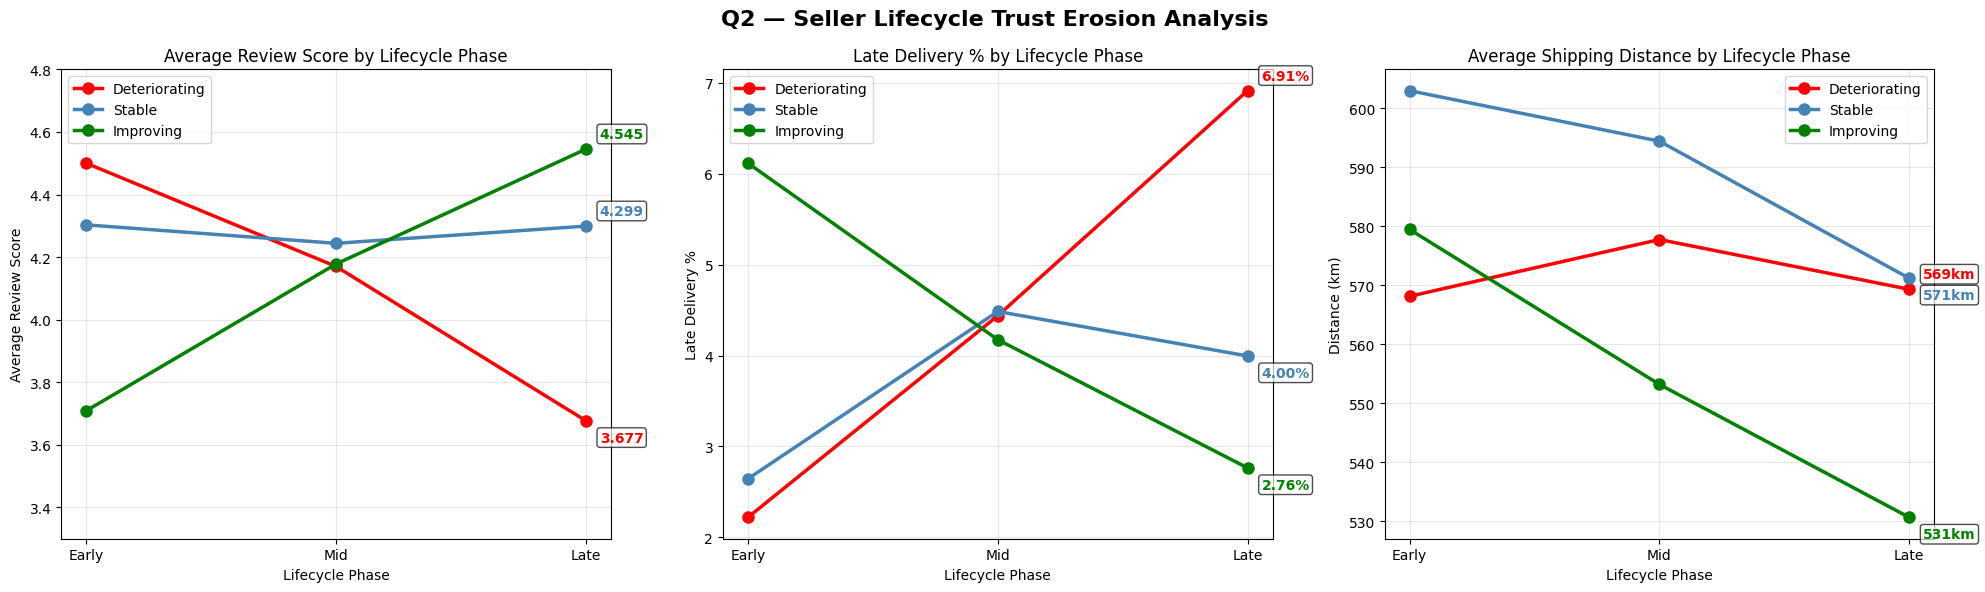

In [71]:
# Visualize the full seller lifecycle story — review score, late delivery %, and shipping distance trajectories by archetype
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Q2 — Seller Lifecycle Trust Erosion Analysis',
             fontsize=16, fontweight='bold')

phases = ['Early', 'Mid', 'Late']
colors = {'deteriorating': 'red', 'stable': 'steelblue', 'improving': 'green'}
offsets = {'deteriorating': (10, -15), 'stable': (10, 8), 'improving': (10, 8)}
offsets_pct = {'deteriorating': (10, 8), 'stable': (10, -15), 'improving': (10, -15)}
offsets_dist = {'deteriorating': (10, 8), 'stable': (10, -15), 'improving': (10, -15)}

for archetype in ['deteriorating', 'stable', 'improving']:
    row = lifecycle_reviews.loc[archetype]
    axes[0].plot(phases, [row['early'], row['mid'], row['late']],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[archetype], label=archetype.capitalize())
    axes[0].annotate(f"{row['late']:.3f}",
                    xy=(2, row['late']),
                    xytext=offsets[archetype],
                    textcoords='offset points',
                    color=colors[archetype], fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[0].set_title('Average Review Score by Lifecycle Phase')
axes[0].set_ylabel('Average Review Score')
axes[0].set_xlabel('Lifecycle Phase')
axes[0].legend()
axes[0].set_ylim(3.3, 4.8)
axes[0].grid(True, alpha=0.3)

late_pct_data = seller_wide.groupby('seller_archetype').agg(
    early=('late_delivery_pct_early', 'mean'),
    mid=('late_delivery_pct_mid', 'mean'),
    late=('late_delivery_pct_late', 'mean')
).round(3)

for archetype in ['deteriorating', 'stable', 'improving']:
    row = late_pct_data.loc[archetype]
    axes[1].plot(phases, [row['early'], row['mid'], row['late']],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[archetype], label=archetype.capitalize())
    axes[1].annotate(f"{row['late']:.2f}%",
                    xy=(2, row['late']),
                    xytext=offsets_pct[archetype],
                    textcoords='offset points',
                    color=colors[archetype], fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[1].set_title('Late Delivery % by Lifecycle Phase')
axes[1].set_ylabel('Late Delivery %')
axes[1].set_xlabel('Lifecycle Phase')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for archetype in ['deteriorating', 'stable', 'improving']:
    row = lifecycle_distance.loc[archetype]
    axes[2].plot(phases, [row['early'], row['mid'], row['late']],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[archetype], label=archetype.capitalize())
    axes[2].annotate(f"{row['late']:.0f}km",
                    xy=(2, row['late']),
                    xytext=offsets_dist[archetype],
                    textcoords='offset points',
                    color=colors[archetype], fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[2].set_title('Average Shipping Distance by Lifecycle Phase')
axes[2].set_ylabel('Distance (km)')
axes[2].set_xlabel('Lifecycle Phase')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
# Calculate each seller's tenure (days between their first and last order) to check whether archetypes differ in how long they've been active
seller_tenure = q2_order_level.groupby('seller_id').agg(
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max')
).reset_index()

seller_tenure['tenure_days'] = (
    seller_tenure['last_order'] - seller_tenure['first_order']
).dt.days

print("SELLER TENURE DISTRIBUTION:")
display(seller_tenure['tenure_days'].describe().round(2))

SELLER TENURE DISTRIBUTION:


count    941.00
mean     350.11
std      163.82
min       13.00
25%      219.00
50%      343.00
75%      493.00
max      690.00
Name: tenure_days, dtype: float64

In [73]:
# Compare tenure across archetypes — deteriorating and improving sellers can be spotted purely from their review trajectory shape
seller_tenure_archetype = seller_tenure.merge(
    seller_wide[['seller_id', 'seller_archetype']],
    on='seller_id'
)

print("TENURE BY ARCHETYPE:")
display(seller_tenure_archetype.groupby('seller_archetype').agg(
    avg_tenure_days=('tenure_days', 'mean'),
    median_tenure_days=('tenure_days', 'median'),
    min_tenure=('tenure_days', 'min'),
    max_tenure=('tenure_days', 'max'),
    seller_count=('seller_id', 'count')
).round(2))

TENURE BY ARCHETYPE:


,avg_tenure_days,median_tenure_days,min_tenure,max_tenure,seller_count
seller_archetype,,,,,
deteriorating,340.93,350.0,19,680,144
improving,298.96,272.0,26,685,139
stable,362.93,362.5,13,690,658


### Q2 — Key Findings

| Archetype | Count | % | Early Review | Late Review | Change |
|---|---|---|---|---|---|
| Stable | 658 | 69.9% | 4.303 | 4.299 | -0.004 |
| Deteriorating | 144 | 15.3% | 4.500 | 3.677 | **-0.823** |
| Improving | 139 | 14.8% | 3.709 | 4.545 | **+0.836** |

**Leading signal of deterioration:** In the mid phase — before the review score has visibly declined — deteriorating sellers already show:
- The largest early-to-mid jump in late delivery rate: **+2.22 percentage points** (vs +1.84 for stable, -1.94 for improving)
- A narrowing promise gap (+1.78 days — delivering less early than they used to)
- A freight ratio change that is small and similar across all three archetypes — pricing is *not* a leading signal

**Answer:** Deteriorating sellers actually start out with the *best* early-phase review score (4.500) of any archetype, then erode to 3.677 by the late phase. The earliest detectable warning sign isn't pricing behavior — it's an accelerating late-delivery rate in the mid phase, well before the review score itself starts to drop.

**Business implication:** Olist should monitor mid-phase increases in a seller's late-delivery rate and proactively offer logistics support before the damage shows up in reviews.


---
## Phase 6 — Predictive Modeling

Having identified late-delivery acceleration as the leading behavioral signal, we test whether early/mid-phase features alone can predict which sellers will end up in the deteriorating archetype. This is a binary classification problem (144 deteriorating vs 797 not, in the 941-seller sample) with meaningful class imbalance, so `class_weight='balanced'` is used throughout.


In [74]:
# Phase 6 setup — build model_data with the deterioration target and early/mid behavioral change features
# is_deteriorating is a binary target; class imbalance (144 deteriorating vs 797 not) is why class_weight='balanced' is used later
print("PHASE 6 — PREDICTIVE LAYER")
print('\n')

from sklearn.model_selection import train_test_split

model_data = seller_wide[['seller_id', 'seller_archetype']].copy()

model_data['is_deteriorating'] = (
    model_data['seller_archetype'] == 'deteriorating'
).astype(int)

model_data['late_pct_change_early_mid'] = seller_wide['late_pct_change_early_mid']
model_data['promise_gap_change_early_mid'] = seller_wide['promise_gap_change_early_mid']
model_data['freight_ratio_change_early_mid'] = seller_wide['freight_ratio_change_early_mid']
model_data['distance_change_early_mid'] = seller_wide['distance_change_early_mid']
model_data['delivery_days_change'] = (
    seller_wide['avg_delivery_days_mid'] -
    seller_wide['avg_delivery_days_early']
).round(3)
model_data['early_review_score'] = seller_wide['avg_review_score_early']
model_data['early_late_pct'] = seller_wide['late_delivery_pct_early']
model_data['early_promise_gap'] = seller_wide['avg_promise_gap_early']
model_data['early_distance'] = seller_wide['avg_shipping_distance_early']
model_data['mid_review_score'] = seller_wide['avg_review_score_mid']
model_data['order_count_early'] = seller_wide['order_count_early']

print(f"Model data shape: {model_data.shape}")
print("\n")
print(f"Target distribution:")
print(model_data['is_deteriorating'].value_counts())
print("\n")
print(f"Class balance:")
print((model_data['is_deteriorating'].value_counts() /
       len(model_data) * 100).round(2))

PHASE 6 — PREDICTIVE LAYER


Model data shape: (941, 14)


Target distribution:
is_deteriorating
0    797
1    144
Name: count, dtype: int64


Class balance:
is_deteriorating
0    84.7
1    15.3
Name: count, dtype: float64


In [75]:
# Define the 11 candidate features and split into train/test sets, stratified on the target to preserve class balance
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

features = [
    'late_pct_change_early_mid',
    'promise_gap_change_early_mid',
    'freight_ratio_change_early_mid',
    'distance_change_early_mid',
    'delivery_days_change',
    'early_review_score',
    'early_late_pct',
    'early_promise_gap',
    'early_distance',
    'mid_review_score',
    'order_count_early'
]

X = model_data[features]
y = model_data['is_deteriorating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print("\n")
print(f"Class distribution in test set:")
print(y_test.value_counts())

Training set: (752, 11)
Test set:     (189, 11)


Class distribution in test set:
is_deteriorating
0    160
1     29
Name: count, dtype: int64


In [76]:
# Fit and evaluate two models: Logistic Regression (scaled features) and Random Forest (raw features)
# Logistic Regression trades precision for recall (catches more deteriorating sellers); Random Forest is more conservative
# ROC-AUC: Logistic Regression 0.709, Random Forest 0.745
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("MODEL 1 — LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred,
      target_names=['not_deteriorating', 'deteriorating']))
print(f"ROC-AUC: {round(roc_auc_score(y_test, lr_prob), 4)}")
print('\n')

print("MODEL 2 — RANDOM FOREST")
print(classification_report(y_test, rf_pred,
      target_names=['not_deteriorating', 'deteriorating']))
print(f"ROC-AUC: {round(roc_auc_score(y_test, rf_prob), 4)}")

MODEL 1 — LOGISTIC REGRESSION
                   precision    recall  f1-score   support

not_deteriorating       0.91      0.62      0.74       160
    deteriorating       0.24      0.66      0.35        29

         accuracy                           0.62       189
        macro avg       0.57      0.64      0.54       189
     weighted avg       0.81      0.62      0.68       189

ROC-AUC: 0.7086


MODEL 2 — RANDOM FOREST
                   precision    recall  f1-score   support

not_deteriorating       0.85      0.99      0.92       160
    deteriorating       0.50      0.03      0.06        29

         accuracy                           0.85       189
        macro avg       0.68      0.51      0.49       189
     weighted avg       0.80      0.85      0.79       189

ROC-AUC: 0.7448


RANDOM FOREST — FEATURE IMPORTANCE:


,Feature,Importance
5,early_review_score,0.186840
7,early_promise_gap,0.098943
9,mid_review_score,0.096782
3,distance_change_early_mid,0.092354
2,freight_ratio_change_early_mid,0.091980
1,promise_gap_change_early_mid,0.089784
4,delivery_days_change,0.088712
10,order_count_early,0.084741
8,early_distance,0.083012
0,late_pct_change_early_mid,0.054510




LOGISTIC REGRESSION — COEFFICIENTS:


,Feature,Coefficient
5,early_review_score,0.9351
2,freight_ratio_change_early_mid,0.2031
4,delivery_days_change,0.1209
1,promise_gap_change_early_mid,0.0756
3,distance_change_early_mid,0.0207
7,early_promise_gap,0.0151
8,early_distance,-0.0496
0,late_pct_change_early_mid,-0.2222
6,early_late_pct,-0.2252
9,mid_review_score,-0.3950


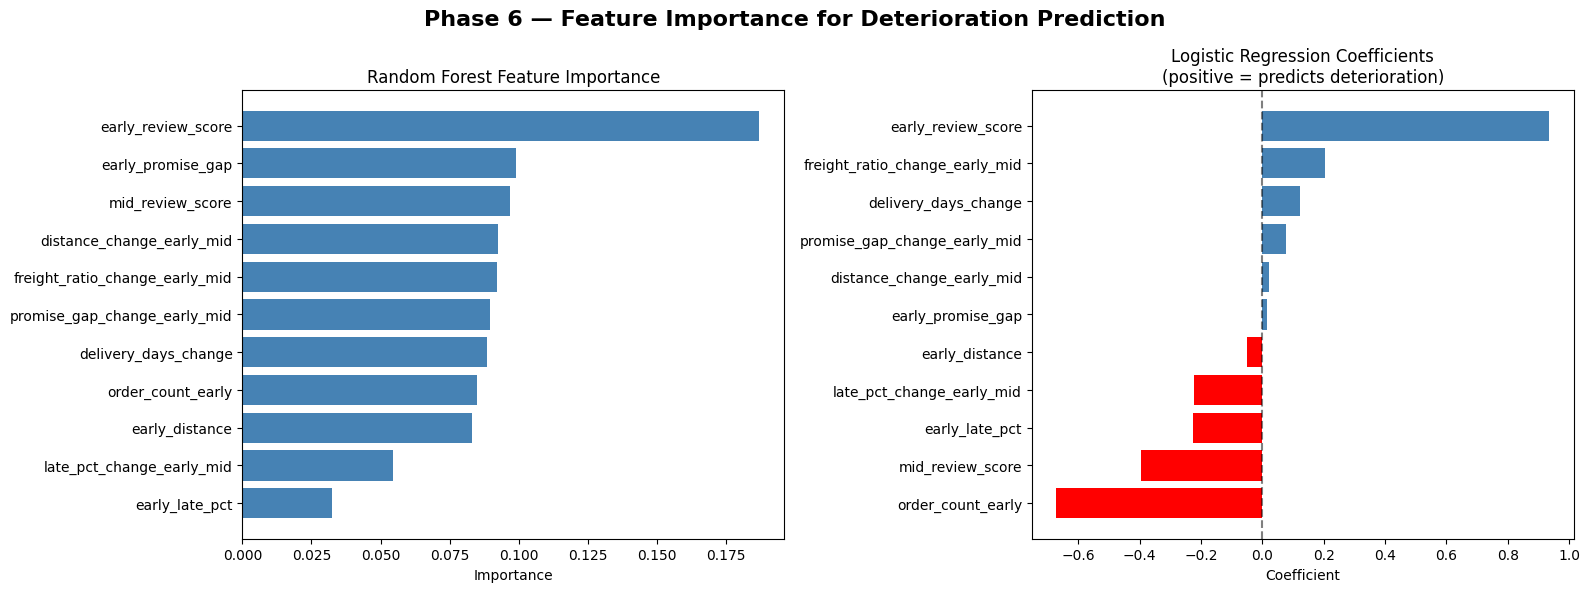

In [77]:
# Compare Random Forest feature importances against Logistic Regression coefficients to see which signals matter most
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("RANDOM FOREST — FEATURE IMPORTANCE:")
display(feature_importance)
print('\n')

lr_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("LOGISTIC REGRESSION — COEFFICIENTS:")
display(lr_coef)
print('\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 6 — Feature Importance for Deterioration Prediction',
             fontsize=16, fontweight='bold')

axes[0].barh(feature_importance['Feature'],
             feature_importance['Importance'],
             color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

colors_coef = ['red' if c < 0 else 'steelblue' for c in lr_coef['Coefficient']]
axes[1].barh(lr_coef['Feature'], lr_coef['Coefficient'], color=colors_coef)
axes[1].set_title('Logistic Regression Coefficients\n(positive = predicts deterioration)')
axes[1].set_xlabel('Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [78]:
# 5-fold stratified cross-validation to check how stable each model's ROC-AUC is beyond a single train/test split
# Logistic Regression: mean 0.716 (std 0.017); Random Forest: mean 0.681 (std 0.036) — Logistic Regression is both stronger and more stable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    lr_model, X_train_scaled, y_train,
    cv=cv, scoring='roc_auc'
)

rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='roc_auc'
)

print("CROSS VALIDATION — ROC-AUC (5 fold)")
print('\n')
print(f"Logistic Regression:")
print(f"  Scores: {lr_cv_scores.round(4)}")
print(f"  Mean:   {lr_cv_scores.mean().round(4)}")
print(f"  Std:    {lr_cv_scores.std().round(4)}")
print('\n')
print(f"Random Forest:")
print(f"  Scores: {rf_cv_scores.round(4)}")
print(f"  Mean:   {rf_cv_scores.mean().round(4)}")
print(f"  Std:    {rf_cv_scores.std().round(4)}")

CROSS VALIDATION — ROC-AUC (5 fold)


Logistic Regression:
  Scores: [0.7228 0.7177 0.6844 0.7227 0.734 ]
  Mean:   0.7163
  Std:    0.0168


Random Forest:
  Scores: [0.696  0.6564 0.6686 0.6416 0.7429]
  Mean:   0.6811
  Std:    0.0357


---
## Summary

- **Q1:** Freight ratio has a statistically significant but practically negligible relationship with review score. Delivery reliability (whether an order arrives late) is the dominant driver of customer satisfaction, with an effect roughly 5-10x larger than freight pricing.
- **Q2:** Sellers do follow a detectable lifecycle. Deteriorating sellers can look identical to stable sellers early on, but an accelerating late-delivery rate in the mid phase is a leading indicator that shows up before the review score itself declines — giving Olist a window to intervene.
- **Modeling:** A logistic regression on early/mid-phase behavioral change features achieves ROC-AUC ≈ 0.72 in 5-fold cross-validation, confirming the signal is real (if modest) and not just a pattern in a single train/test split.
